## 0.Setup

### 0-0 Environment

To Run This Notebook:
- **Environment**: >= Python 3.11.

- **Package Installation**: `geopandas` is required; if the installation fails, ensure you have system-level spatial tools (like `PROJ`) installed. You can uncomment the first cell to install dependencies. 

- **Connectivity**: Ensure you use USYD Wi-Fi to pass Google API permission, and your firewall/antivirus permits the remote Neon Database connection.

In [1]:
import subprocess, sys

issues = []
try:
    import pyproj
except ImportError:
    issues.append("pyproj")
try:
    import fiona
except ImportError:
    issues.append("fiona")
try:
    import geopandas
except ImportError:
    issues.append("geopandas")

if issues:
    print(f"⚠️  Missing: {', '.join(issues)}")
    print("\n These require system-level libraries (PROJ/GDAL).")
    print("Please run ONE of the following BEFORE continuing:")
    print("\n  [Mac]    brew install proj gdal")
    print("           pip install pyproj geopandas fiona shapely")
    print("\n  [Conda]  conda install -c conda-forge geopandas")
    print("\n  [Windows] conda install -c conda-forge geopandas")
    print("\nThen restart the kernel and re-run from Cell 1.")
    print("=" * 60)
    raise EnvironmentError("Please install geospatial dependencies first — see instructions above.")
else:
    print("✓ All geospatial dependencies found. Safe to continue.")

%pip install -r requirements.txt
"""
# Data download / file parsing
%pip install 'requests>=2.28'
%pip install 'openpyxl>=3.1.0'

# Database
%pip install 'psycopg2-binary>=2.9'

# Data manipulation
%pip install 'pandas>=2.0'
%pip install 'numpy>=1.24'

# Fuzzy matching
%pip install 'thefuzz>=0.20'
%pip install 'rapidfuzz>=3.0'

# Geospatial
%pip install 'geopandas>=0.14'
%pip install 'shapely>=2.0'
%pip install 'fiona>=1.9'
%pip install 'pyproj>=3.6'

# Visualisation
%pip install 'matplotlib>=3.7'
%pip install 'seaborn>=0.13'

# Notebook
%pip install 'jupyter>=1.0'
%pip install 'nbformat>=5.7'

"""

✓ All geospatial dependencies found. Safe to continue.
  Obtaining dependency information for thefuzz>=0.20 from https://files.pythonhosted.org/packages/82/4f/1695e70ceb3604f19eda9908e289c687ea81c4fecef4d90a9d1d0f2f7ae9/thefuzz-0.22.1-py3-none-any.whl.metadata
  Using cached thefuzz-0.22.1-py3-none-any.whl.metadata (3.9 kB)
  Obtaining dependency information for rapidfuzz>=3.0 from https://files.pythonhosted.org/packages/e1/f9/3c41a7be8855803f4f6c713b472226a98d31d41869d98f64f4ca790510d6/rapidfuzz-3.14.5-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Using cached rapidfuzz-3.14.5-cp311-cp311-macosx_10_9_x86_64.whl.metadata (12 kB)
  Obtaining dependency information for fqdn from https://files.pythonhosted.org/packages/cf/58/8acf1b3e91c58313ce5cb67df61001fc9dcd21be4fadb76c1a2d540e09ed/fqdn-1.5.1-py3-none-any.whl.metadata
  Obtaining dependency information for isoduration from https://files.pythonhosted.org/packages/7b/55/e5326141505c5d5e34c5e0935d2908a74e4561eca44108fbfb9c13d2911a/isodura

"\n# Data download / file parsing\n%pip install 'requests>=2.28'\n%pip install 'openpyxl>=3.1.0'\n\n# Database\n%pip install 'psycopg2-binary>=2.9'\n\n# Data manipulation\n%pip install 'pandas>=2.0'\n%pip install 'numpy>=1.24'\n\n# Fuzzy matching\n%pip install 'thefuzz>=0.20'\n%pip install 'rapidfuzz>=3.0'\n\n# Geospatial\n%pip install 'geopandas>=0.14'\n%pip install 'shapely>=2.0'\n%pip install 'fiona>=1.9'\n%pip install 'pyproj>=3.6'\n\n# Visualisation\n%pip install 'matplotlib>=3.7'\n%pip install 'seaborn>=0.13'\n\n# Notebook\n%pip install 'jupyter>=1.0'\n%pip install 'nbformat>=5.7'\n\n"

### 0-1 Imports, Constants, paths

In [2]:
from __future__ import annotations

# Standard library
import os
import re
import csv
import json
import sqlite3
import time as t
import datetime
from collections import defaultdict
from pathlib import Path

# HTTP / data download
import requests
import openpyxl

# Database
import psycopg2
from psycopg2 import extras

# Data manipulation
import pandas as pd
import numpy as np

# Fuzzy matching
from thefuzz import fuzz

# Geospatial
import geopandas as gpd
from shapely import wkb

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Paths and constants
file_info = {
    "NGER_2023":["NGER.ID0243.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0243.csv"],
    "NGER_2022":["NGER.ID0083.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0083.csv"],
    "NGER_2021":["NGER.ID0082.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0082.csv"],
    "NGER_2020":["NGER.ID0081.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0081.csv"],
    "NGER_2019":["NGER.ID0080.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0080.csv"],
    "NGER_2018":["NGER.ID0079.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0079.csv"],
    "NGER_2017":["NGER.ID0078.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0078.csv"],
    "NGER_2016":["NGER.ID0077.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0077.csv"],
    "NGER_2015":["NGER.ID0076.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0076.csv"],
    "NGER_2014":["NGER.ID0075.csv","https://api.cer.gov.au/datahub-public/v1/api/Dataset/NGER/dataset/ID0075.csv"],
    "LGCS":["power-stations-and-projects-status.csv","https://cer.gov.au//document/power-stations-and-projects-accredited"],
    "ECON":["14100DO0003_2011-24.xlsx","https://abs.gov.au//methodologies/data-region-methodology/2011-24/14100DO0003_2011-24.xlsx"]
}

datasets = {
    'NGER': pd.DataFrame(),
    'LGCS': pd.DataFrame(),
    'ECON': pd.DataFrame()
}

STATE_TO_ABS_LABEL = {
    "NSW": "New South Wales",
    "VIC": "Victoria",
    "QLD": "Queensland",
    "SA":  "South Australia",
    "WA":  "Western Australia",
    "TAS": "Tasmania",
    "NT":  "Northern Territory",
    "ACT": "Australian Capital Territory",
}

RENEWABLE_FUELS = {
    "Wind", "Solar", "Hydro", "Bagasse", "Landfill", "Biogas", "Biomass",
    "Black Liquor", "Waste coal mine gas", "Geothermal",
}

GOOGLE_API = os.environ.get('GOOGLE_MAPS_API_KEY', '')  # set in .env
# only for USYD IP and 10 times per day - expired after 2026-05-15

pd.options.display.max_columns = 50

econ_sum_checks = [
    (
        "total_number_of_businesses vs size bands",
        "total_number_of_businesses",
        [
            "number_of_non-employing_businesses",
            "number_of_employing_businesses:_1-4_employees",
            "number_of_employing_businesses:_5-19_employees",
            "number_of_employing_businesses:_20_or_more_employees",
        ],
    ),
    (
        "total_number_of_business_entries vs components",
        "total_number_of_business_entries",
        [
            "number_of_non-employing_business_entries",
            "number_of_employing_business_entries:_1-4_employees",
            "number_of_employing_business_entries:_5-19_employees",
            "number_of_employing_business_entries:_20_or_more_employees",
        ],
    ),
    (
        "total_number_of_business_exits vs components",
        "total_number_of_business_exits",
        [
            "number_of_non-employing_business_exits",
            "number_of_employing_business_exits:_1-4_employees",
            "number_of_employing_business_exits:_5-19_employees",
            "number_of_employing_business_exits:_20_or_more_employees",
        ],
    ),
    (
        "total_dwellings_(no.) vs dwelling-type totals",
        "total_dwellings_(no.)",
        ["houses_-_total_(no.)", "townhouses_-_total_(no.)", "apartments_-_total_(no.)"],
    ),
    (
        "total_dwelling_additions_(no.) vs additions by type",
        "total_dwelling_additions_(no.)",
        ["houses_-_additions_(no.)", "townhouses_-_additions_(no.)", "apartments_-_additions_(no.)"],
    ),
    (
        "total_dwelling_removals_(no.) vs removals by type",
        "total_dwelling_removals_(no.)",
        ["houses_-_removals_(no.)", "townhouses_-_removals_(no.)", "apartments_-_removals_(no.)"],
    ),
]


### 0-2 Connect to the database

In [3]:
NEON = {
    "host": os.environ.get("NEON_HOST", "ep-curly-shadow-am210xai-pooler.c-5.us-east-1.aws.neon.tech"),
    "port": int(os.environ.get("NEON_PORT", "5432")),
    "user": os.environ.get("NEON_USER", "neondb_owner"),
    "password": os.environ.get("NEON_PASSWORD","npg_bhUagS5eIH1m"), #for assignment only, so no encyption on password
    "sslmode": "require",
    "connect_timeout": 20,
}

def try_connect(dbname: str):
    cfg = {**NEON, "dbname": dbname}
    return psycopg2.connect(**cfg)

conn = try_connect("neondb")

if conn is None:
    raise RuntimeError("Failed to connect to both COMP5339_Assi1 and neondb.")

cur = conn.cursor()
cur.execute("SELECT current_database(), current_user;")
cur.execute("SELECT version();")

try:
    dim_faci = pd.read_sql("SELECT * FROM dim_facility", conn)
    fac_geo = dim_faci.copy()
    print('dim_facility table loaded.')
    
    dim_lgcs = pd.read_sql("SELECT * FROM dim_lgcs", conn)
    pws_geo = dim_lgcs[['accreditation_code', 'new_station_name', 'state', 'postcode','latitude','longitude','name_on_map','source','sa2_code','geom']]
    print('dim_lgcs table loaded. \n\nLoading geo_regions table... (~1m)')
    
    geo_regions = pd.read_sql("SELECT * FROM geo_regions", conn)
    print('geo_regions table loaded, transforming to GeoDataFrame...')
    geo_regions['geometry'] = geo_regions['geom'].apply(lambda g: wkb.loads(g, hex=True) if pd.notna(g) and g else None)
    geo_regions = gpd.GeoDataFrame(geo_regions, geometry='geometry', crs="EPSG:4326")
    print('geo_regions table transformed.')

except:
    entity_with_geo = pd.read_csv("entity_with_geo.txt", sep="\t")
    fac_geo = entity_with_geo[entity_with_geo['___'] == '_facility_'].copy()
    fac_geo.rename(columns={'entity_name':'facility_name'}, inplace=True)
    fac_geo.drop(columns=['___'], inplace=True)
    
    pws_geo = entity_with_geo[(entity_with_geo['___'] != '_facility_') & (entity_with_geo['___'] != '_region_')].copy()
    pws_geo.rename(columns={'entity_name':'accreditation_code','___':'new_station_name'}, inplace=True)

    geo_regions = entity_with_geo[entity_with_geo['___'] == '_region_'].copy()
    geo_regions.rename(columns={'entity_name':'code', 'state':'layer', 'postcode':'geo_name', 'latitude':'central_lat', 'longitude':'central_lng',
                                'name_on_map':'postcode_list','source':'parent_code'}, inplace=True)
    geo_regions["geometry"] = geo_regions["geom"].apply(lambda g: wkb.loads(g, hex=True) if pd.notna(g) and g else None)
    geo_regions = gpd.GeoDataFrame(geo_regions, geometry="geometry", crs="EPSG:4326")
    
    print('Connection to Neon DB failed, read geo_info from local file.')

cur.close()
conn.close()


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1018362676.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_faci = pd.read_sql("SELECT * FROM dim_facility", conn)


dim_facility table loaded.


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1018362676.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_lgcs = pd.read_sql("SELECT * FROM dim_lgcs", conn)


dim_lgcs table loaded. 

Loading geo_regions table... (~1m)


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1018362676.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  geo_regions = pd.read_sql("SELECT * FROM geo_regions", conn)


geo_regions table loaded, transforming to GeoDataFrame...
geo_regions table transformed.


## 1. Data acquisition

### 1-1 Def founction

In [4]:
def download_file(url: str, dest: Path, timeout: int = 120) -> bool:
    try:
        r = requests.get(
            url,
            timeout=timeout,
            headers={"User-Agent": "COMP5339"},
        )
        r.raise_for_status()
        dest.write_bytes(r.content)
        return True
    except Exception as e:
        print(f"Download failed ({dest.name}): {e}")
        return False

def check_file_exists(filename: str, url: str):
    """Find CSV/XLSX whether kernel cwd is `Assi1/` or the parent folder (e.g. project root)."""
    name = Path(filename).name
    cwd = Path.cwd()
    paths_to_check = [
        Path(filename),
        cwd / filename,
        cwd / name,
        cwd / "Assi1" / name,
        Path("Assi1") / name,
        Path("data") / name,
        Path("raw") / name,
    ]
    for new_path in paths_to_check:
        if new_path.exists():
            return str(new_path.resolve())

    print(f"{filename} not found, downloading...")
    # Ensure 'data' directory exists and set it as the destination path
    data_dir = cwd / "data"
    data_dir.mkdir(parents=True, exist_ok=True)
    dest_path = data_dir / name

    if download_file(url, dest_path):
        return str(dest_path.resolve())
    print(f"Failed to download {filename}")
    return None

# Matches your convert_xlsx_to_csv(..., skip_rows=6): first 6 rows skipped; row 7 = header

def load_econ_xlsx(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    xl = pd.ExcelFile(path, engine="openpyxl")
    raw_names = list(xl.sheet_names)
    print(f"ECON workbook {path.name} sheets: {raw_names}")

    def _resolve_sheet(want: str) -> str | None:
        """Match 'Table 1' / 'Table 2' even if spacing/case differs."""
        w = want.replace(" ", "").lower()
        for n in raw_names:
            if n.replace(" ", "").lower() == w:
                return n
        return None

    parts = []
    try:
        for tab_name in ("Table 1", "Table 2"):
            sn = _resolve_sheet(tab_name)
            if sn is None:
                print(f"WARNING: no sheet matching {tab_name!r}; skipping. Available: {raw_names}")
                continue
            df = pd.read_excel(xl, sheet_name=sn, header=6, na_values=['-', 'NA', 'n/a', ''])
            df["source_table"] = tab_name  # only "Table 1" or "Table 2"
            print(f"  {tab_name}: {len(df):,} rows (matched sheet {sn!r})")
            parts.append(df)
        # Fallback: sheet titles are not literally "Table 1" / "Table 2" — use sheets at index 1 and 2 (after Contents).
        if len(parts) < 2 and len(raw_names) >= 3:
            sheet_t1, sheet_t2 = raw_names[1], raw_names[2]
            if len(parts) == 0:
                for sheet_name, tab_name in ((sheet_t1, "Table 1"), (sheet_t2, "Table 2")):
                    df = pd.read_excel(xl, sheet_name=sheet_name, header=6)
                    df["source_table"] = tab_name
                    parts.append(df)
            elif len(parts) == 1 and parts[0]["source_table"].iloc[0] == "Table 1":
                df = pd.read_excel(xl, sheet_name=sheet_t2, header=6)
                df["source_table"] = "Table 2"
                parts.append(df)
    finally:
        xl.close()
    if not parts:
        raise ValueError("ECON: could not load any sheet from the workbook")
    out = pd.concat(parts, ignore_index=True)
    return out

def lowercase_snake_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with column names: lower case, spaces -> single underscore, strip edges."""
    out = df.copy()
    out.columns = (
        out.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
    )
    return out


### 1-2 Download and Read File

In [5]:
for key, (filename, url) in file_info.items():
    filepath = check_file_exists(filename, url)
    if filepath is None:
        print(f"Skipping {key}: could not find or download {filename}")
        continue
    print(f'Transforming {key} from {filepath}...')
    ext = Path(filepath).suffix.lower()
    try:
        df = None
        if ext == '.csv':
            df = pd.read_csv(filepath, on_bad_lines='skip', na_values='-')
            df = lowercase_snake_columns(df)
            if key.startswith("NGER"):
                df['source_year'] = key.split('_')[-1]

        elif ext == '.xlsx':
            df = load_econ_xlsx(filepath)
            df = lowercase_snake_columns(df)
        else:
            print(f"Unsupported file type: {ext}")
            continue

        if df is not None:
            if key.startswith("NGER"):
                datasets['NGER'] = pd.concat([datasets['NGER'], df], ignore_index=True)
            else:
                datasets[key] = df
    except Exception as e:
        print(f"Error reading {key}: {e}")


NGER.ID0243.csv not found, downloading...
Transforming NGER_2023 from /Users/chingyu/Documents/Comp5339 Engineering/Assi1/5339_Assignment1_Group4/data/NGER.ID0243.csv...
NGER.ID0083.csv not found, downloading...
Transforming NGER_2022 from /Users/chingyu/Documents/Comp5339 Engineering/Assi1/5339_Assignment1_Group4/data/NGER.ID0083.csv...
NGER.ID0082.csv not found, downloading...
Transforming NGER_2021 from /Users/chingyu/Documents/Comp5339 Engineering/Assi1/5339_Assignment1_Group4/data/NGER.ID0082.csv...
NGER.ID0081.csv not found, downloading...
Transforming NGER_2020 from /Users/chingyu/Documents/Comp5339 Engineering/Assi1/5339_Assignment1_Group4/data/NGER.ID0081.csv...
NGER.ID0080.csv not found, downloading...
Transforming NGER_2019 from /Users/chingyu/Documents/Comp5339 Engineering/Assi1/5339_Assignment1_Group4/data/NGER.ID0080.csv...
NGER.ID0079.csv not found, downloading...
Transforming NGER_2018 from /Users/chingyu/Documents/Comp5339 Engineering/Assi1/5339_Assignment1_Group4/data

### 1-3 Acquire Geographic Reference Data

Check that the pre-built ASGS geographic reference file is available. The shapefile download and spatial processing are handled in Section 3-5/3-6; here we only verify the file exists so Section 2 can use it for ECON code validation.


In [6]:
# --- 1-3. Geo Reference — Raw Shapefile Loading ---
# Read every ASGS shapefile into raw_geo_layers (dict[slug -> GeoDataFrame]).
# Heavy processing (area, centroid, postcodes, parent_code) happens in 3-5 / 3-6.

if geo_regions.empty:
    GEO_INFO_DIR = Path("geo_info")
    PREPARED_DIR  = GEO_INFO_DIR / "prepared"
    PREPARED_DIR.mkdir(exist_ok=True)

    def layer_slug(folder_name: str) -> str:
        s = folder_name.lower()
        for suffix in ("_aust_shp_gda2020", "_aust_gda2020_shp", "_aust_gda2020"):
            if s.endswith(suffix):
                return s[: -len(suffix)]
        return s

    # raw_geo_layers: dict[slug -> GeoDataFrame(layer, code, geo_name, geometry)]
    # raw_poa_gdf:   postcode area layer — used in 3-6 for spatial postcode join
    raw_geo_layers: dict[str, gpd.GeoDataFrame] = {}
    raw_poa_gdf: gpd.GeoDataFrame | None = None

    for _sub in sorted(GEO_INFO_DIR.iterdir()):
        if not _sub.is_dir() or _sub.name == "prepared":
            continue
        _shps = sorted(_sub.glob("*.shp"))
        if not _shps:
            print(f"  Warning: no .shp in {_sub.name}, skipping")
            continue
        _slug = layer_slug(_sub.name)
        _gdf  = gpd.read_file(_shps[0])
        _cols = _gdf.columns.tolist()
        _code_col = sorted([c for c in _cols if re.search(r"_code\d{2}$", c, re.I)], key=len)[0]
        _name_col = sorted([c for c in _cols if re.search(r"_name\d{2}$", c, re.I)], key=len)[0]
        _code = _gdf[_code_col].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
        _raw  = gpd.GeoDataFrame(
            {"layer": _slug, "code": _code, "geo_name": _gdf[_name_col]},
            geometry=_gdf.geometry, crs=_gdf.crs
        )
        if _slug == "poa_2021":
            raw_poa_gdf = _raw
        else:
            raw_geo_layers[_slug] = _raw
        print(f"  {_slug}: {len(_raw)} regions")

    print(f"\nLoaded layers: {list(raw_geo_layers.keys())}")
    if raw_poa_gdf is not None:
        print(f"  poa_2021: {len(raw_poa_gdf)} postcode areas (used for postcode join in 3-6)")
else:
    raw_geo_layers={}
    raw_geo_layers['All_Layers'] = geo_regions.copy()
    print('use geo_regions from DB.')


use geo_regions from DB.


## 2. Integration and cleaning

### 2-1 Observation for later cleaning

In [7]:
for (df_name, df) in datasets.items():
  print("\n",df_name)
  print(f'shape{df.shape}')
  display(df.head())



 NGER
shape(5942, 21)


,reporting_entity,facility_name,type,state,electricity_production_gj,electricity_production_mwh,total_scope_1_emissions_t_co2_e,total_scope_2_emissions_t_co2_e,total_emissions_t_co2_e,emission_intensity_t_co2_e_mwh,grid_connected,grid,primary_fuel,important_notes,source_year,total_scope_2_emissions_t_co2_e_2,emission_intensity_t_mwh,grid_connected2,controlling_corporation,scope_1_t_co2_e,scope_2_t_co2_e
0,ACCIONA ENERGY OCEANIA PTY LTD,Cathedral Rocks Wind Farm,F,SA,481948.0,133874.0,57.0,127.0,184,0.0,On,NEM,Wind,NaN,2023,NaN,NaN,NaN,NaN,NaN,NaN
1,ACCIONA ENERGY OCEANIA PTY LTD,Gunning Wind Farm,F,NSW,491409.0,136502.0,50.0,218.0,268,0.0,On,NEM,Wind,NaN,2023,NaN,NaN,NaN,NaN,NaN,NaN
2,ACCIONA ENERGY OCEANIA PTY LTD,Mortlake South Wind Farm,F,VIC,1019352.0,283153.0,202.0,1128.0,1330,0.0,On,NEM,Wind,NaN,2023,NaN,NaN,NaN,NaN,NaN,NaN
3,ACCIONA ENERGY OCEANIA PTY LTD,Mt Gellibrand Wind Farm,F,VIC,1025451.0,284847.0,99.0,1273.0,1372,0.0,On,NEM,Wind,NaN,2023,NaN,NaN,NaN,NaN,NaN,NaN
4,ACCIONA ENERGY OCEANIA PTY LTD,Waubra Wind Farm,F,VIC,1954964.0,543046.0,186.0,1114.0,1300,0.0,On,NEM,Wind,NaN,2023,NaN,NaN,NaN,NaN,NaN,NaN



 LGCS
shape(57, 8)


,accreditation_code,power_station_name,state,postcode,installed_capacity_(mw),fuel_source(s),accreditation_start_date,approval_date
0,SRPXQLO8,DONS FORT - SOLAR W SGU - QLD,QLD,4660,0.421,Solar,21/10/2025,6/01/2026
1,SRPYNSK0,Mintus Coles - Solar w SGU- NSW,NSW,2153,0.190,Solar,9/12/2025,6/01/2026
2,SRPXQLP1,Ventora - Acacia Ridge - Solar - QLD,QLD,4110,0.162,Solar,17/11/2025,6/01/2026
3,SRPYNSK3,Bayside Aged Care - Solar - Morisset - NSW,NSW,2264,0.140,Solar,16/12/2025,8/01/2026
4,SRPVWAQ0,Matrix Composites and Engineering Pty Ltd - So...,WA,6166,0.850,Solar,17/12/2025,8/01/2026



 ECON
shape(34574, 128)


,code,label,year,number_of_non-employing_businesses,number_of_employing_businesses:_1-4_employees,number_of_employing_businesses:_5-19_employees,number_of_employing_businesses:_20_or_more_employees,total_number_of_businesses,number_of_non-employing_business_entries,number_of_employing_business_entries:_1-4_employees,number_of_employing_business_entries:_5-19_employees,number_of_employing_business_entries:_20_or_more_employees,total_number_of_business_entries,number_of_non-employing_business_exits,number_of_employing_business_exits:_1-4_employees,number_of_employing_business_exits:_5-19_employees,number_of_employing_business_exits:_20_or_more_employees,total_number_of_business_exits,"agriculture,_forestry_and_fishing_(no.)",mining_(no.),manufacturing_(no.),"electricity,_gas,_water_and_waste_services_(no.)",construction_(no.),wholesale_trade_(no.),retail_trade_(no.),...,information_media_and_telecommunications_(%),financial_and_insurance_services_(%),"rental,_hiring_and_real_estate_services_(%)","professional,_scientific_and_technical_services_(%)",administrative_and_support_services_(%),public_administration_and_safety_(%),education_and_training_(%),health_care_and_social_assistance_(%),arts_and_recreation_services_(%),other_services_(%),industry_of_employment_inadequately_described_or_not_stated_(%),total_persons_employed_aged_15_years_and_over_(no.),houses_-_additions_(no.),houses_-_removals_(no.),houses_-_total_(no.),townhouses_-_additions_(no.),townhouses_-_removals_(no.),townhouses_-_total_(no.),apartments_-_additions_(no.),apartments_-_removals_(no.),apartments_-_total_(no.),total_dwelling_additions_(no.),total_dwelling_removals_(no.),total_dwellings_(no.),source_table
0,AUS,Australia,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.8,3.8,1.6,7.3,3.2,6.9,8.0,11.6,1.5,3.8,2.3,10058325.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Table 1
1,AUS,Australia,2016.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.7,3.6,1.7,7.3,3.4,6.7,8.7,12.6,1.7,3.7,4.4,10683844.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Table 1
2,AUS,Australia,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113258.0,18542.0,7279135.0,31729.0,480.0,1261457.0,73838.0,564.0,1464325.0,218884.0,19586.0,10022775.0,Table 1
3,AUS,Australia,2018.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113930.0,21657.0,7371408.0,33346.0,919.0,1293884.0,66330.0,605.0,1530050.0,213652.0,23181.0,10213246.0,Table 1
4,AUS,Australia,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122142.0,20697.0,7472853.0,32571.0,712.0,1325743.0,60705.0,985.0,1589770.0,215556.0,22394.0,10406408.0,Table 1


In [8]:
for df_name, df in datasets.items():
    print(f"\n{df_name}:")
    if df.empty:
        print("  Empty DataFrame")
        continue

    for col in df.columns:
        count = df[col].count()  # non-empty count
        unique_count = df[col].nunique() # unique count
        examples = df[col].dropna().unique()[:3].tolist()
        print(f"  {col}({unique_count}): {count}, {examples}")



NGER:
  reporting_entity(317): 5462, ['ACCIONA ENERGY OCEANIA PTY LTD', 'ACEN AUSTRALIA PTY LTD', 'ADANI RENEWABLE ASSET HOLDINGS PTY LTD']
  facility_name(855): 5936, ['Cathedral Rocks Wind Farm', 'Gunning Wind Farm', 'Mortlake South Wind Farm']
  type(3): 5936, ['F', 'C', 'FA']
  state(8): 4880, ['SA', 'NSW', 'VIC']
  electricity_production_gj(5153): 5938, [481948.0, 491409.0, 1019352.0]
  electricity_production_mwh(4969): 5938, [133874.0, 136502.0, 283153.0]
  total_scope_1_emissions_t_co2_e(2861): 5461, [57.0, 50.0, 202.0]
  total_scope_2_emissions_t_co2_e(1367): 5032, [127.0, 218.0, 1128.0]
  total_emissions_t_co2_e(3386): 5942, [184, 268, 1330]
  emission_intensity_t_co2_e_mwh(150): 3725, [0.0, 0.58, 0.88]
  grid_connected(2): 4475, ['On', 'Off']
  grid(6): 4880, ['NEM', 'SWIS', 'Mt Isa']
  primary_fuel(22): 4880, ['Wind', 'Solar', 'Hydro']
  important_notes(11): 37, ['Please note that where more than one person has operational control over a facility at the same time and no nom

### 2-2 Data Cleaning

#### 2-2-1 Initial Cleaning

In [9]:
def _coalesce_duplicate_columns(df):
    """Merge duplicate column labels by taking first non-null per row (concat year-files)."""
    groups = defaultdict(list)
    for i, c in enumerate(df.columns):
        groups[c].append(i)
    data = {}
    for col, ilist in groups.items():
        acc = df.iloc[:, ilist[0]]
        for j in ilist[1:]:
            acc = acc.combine_first(df.iloc[:, j])
        data[col] = acc
    return pd.DataFrame(data, index=df.index)

# 1. Clean NGER: Harmonize column names and types
nger_df = datasets['NGER'].copy()

column_mapping = {
    "controlling_corporation": "reporting_entity",
    "scope_1_t_co2_e": "total_scope_1_emissions_t_co2_e",
    "scope_2_t_co2_e": "total_scope_2_emissions_t_co2_e",
    "total_scope_2_emissions_t_co2_e_2": "total_scope_2_emissions_t_co2_e",
    "emission_intensity_t_mwh": "emission_intensity_t_co2_e_mwh",
    "grid_connected2": "grid_connected",
}
nger_df = nger_df.rename(columns=column_mapping)
nger_df = _coalesce_duplicate_columns(nger_df)
numeric_cols = ['electricity_production_mwh', 'total_scope_1_emissions_t_co2_e', 'total_scope_2_emissions_t_co2_e', 'total_emissions_t_co2_e', 'emission_intensity_t_co2_e_mwh']
for col in numeric_cols:
    if col in nger_df.columns:
        nger_df[col] = pd.to_numeric(nger_df[col], errors='coerce')
datasets['NGER'] = nger_df

# 2. Clean LGCS
lgcs_df = datasets['LGCS'].copy()

# 3. Clean ECON
econ_df = datasets['ECON'].copy()
geo_info = (
    econ_df[["code", "label", "source_table"]]
    .drop_duplicates(subset=["code"])
    .reset_index(drop=True)
)
geo_info = geo_info.dropna(subset=["source_table"])
econ_df = econ_df.drop(columns=["label"])  # keep source_table for §2-2-3 ECON cleaning
for col in econ_df.columns[1:]:
    if col == "source_table":
        econ_df[col] = econ_df[col].astype("string").str.strip()
        continue
    econ_df[col] = pd.to_numeric(econ_df[col], errors='coerce')


print("Data cleaning complete.")
for name, df in datasets.items():
    print(f"{name} shape: {df.shape}")



Data cleaning complete.
NGER shape: (5942, 15)
LGCS shape: (57, 8)
ECON shape: (34574, 128)


In [10]:
for df in (nger_df,lgcs_df,econ_df,geo_info):
    if df.empty:
        print("  Empty DataFrame")
        continue
    print("\n===================")
    for col in df.columns:
        count = df[col].count()  # non-empty count
        unique_count = df[col].nunique() # unique count
        examples = df[col].dropna().unique()[:5].tolist()
        print(f"  {col}~{unique_count}~:~{count}~ {examples}")



  reporting_entity~322~:~5942~ ['ACCIONA ENERGY OCEANIA PTY LTD', 'ACEN AUSTRALIA PTY LTD', 'ADANI RENEWABLE ASSET HOLDINGS PTY LTD', 'AGL ENERGY LIMITED', 'ALCOA AUSTRALIAN HOLDINGS PTY LTD']
  facility_name~855~:~5936~ ['Cathedral Rocks Wind Farm', 'Gunning Wind Farm', 'Mortlake South Wind Farm', 'Mt Gellibrand Wind Farm', 'Waubra Wind Farm']
  type~3~:~5936~ ['F', 'C', 'FA']
  state~8~:~4880~ ['SA', 'NSW', 'VIC', 'QLD', 'WA']
  electricity_production_gj~5153~:~5938~ [481948.0, 491409.0, 1019352.0, 1025451.0, 1954964.0]
  electricity_production_mwh~4969~:~5938~ [133874.0, 136502.0, 283153.0, 284847.0, 543046.0]
  total_scope_1_emissions_t_co2_e~3076~:~5885~ [57.0, 50.0, 202.0, 99.0, 186.0]
  total_scope_2_emissions_t_co2_e~1580~:~5764~ [127.0, 218.0, 1128.0, 1273.0, 1114.0]
  total_emissions_t_co2_e~3386~:~5942~ [184, 268, 1330, 1372, 1300]
  emission_intensity_t_co2_e_mwh~171~:~4830~ [0.0, 0.58, 0.88, 1.18, 0.01]
  grid_connected~2~:~4880~ ['On', 'Off']
  grid~6~:~4880~ ['NEM', 'SW

#### 2-2-2 Cleaning NEGR

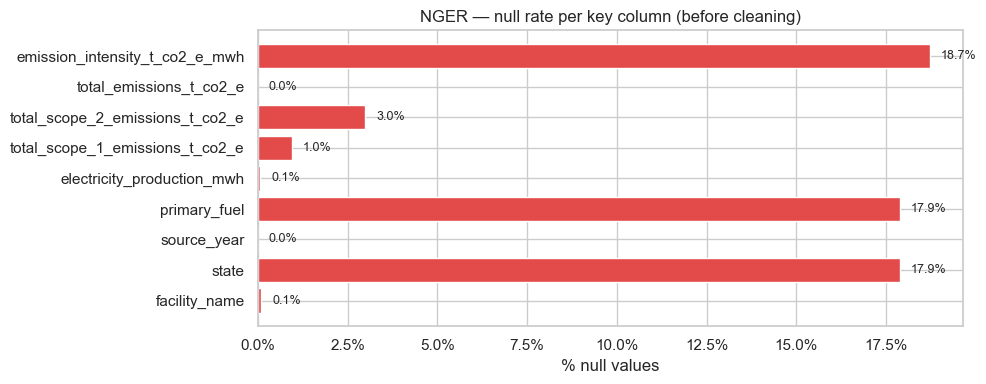

Saved: nger_null_before.png
Step 1 — dropped 0 fully-empty rows
array([], dtype=object)
[]


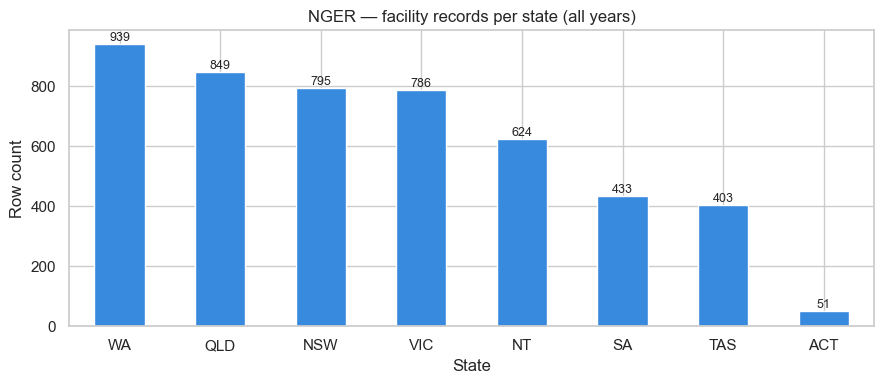

Saved: nger_state_dist.png
Grid connected value counts:
grid_connected
True     3537
False    1343
<NA>     1062
Name: count, dtype: Int64
No negative values found — skipping the visualisation
  Clipped negatives in 'electricity_production_mwh'
  Clipped negatives in 'total_scope_1_emissions_t_co2_e'
  Clipped negatives in 'total_scope_2_emissions_t_co2_e'
  Clipped negatives in 'total_emissions_t_co2_e'
  Clipped negatives in 'emission_intensity_t_co2_e_mwh'


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1811170124.py:175: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1811170124.py:176: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(fig_dir / 'nger_emission_intensity_dist.png', dpi=150)
/Users/chingyu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


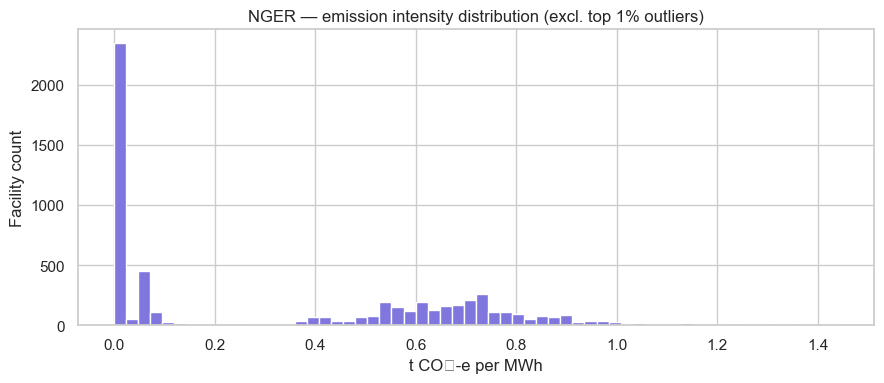

Saved: nger_emission_intensity_dist.png
Step 9 — deduplication removed 1075 rows


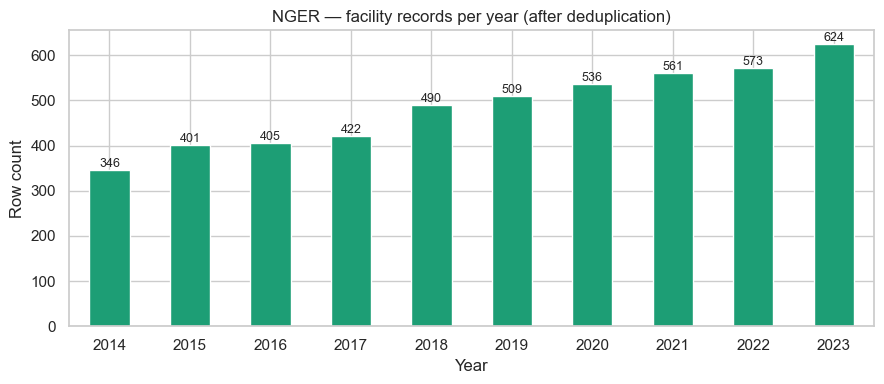

Saved: nger_rows_per_year.png
Removed summary/placeholder rows. Remaining: 4857
Dropping 3 rows with null facility_name or state — cannot be linked to a facility.


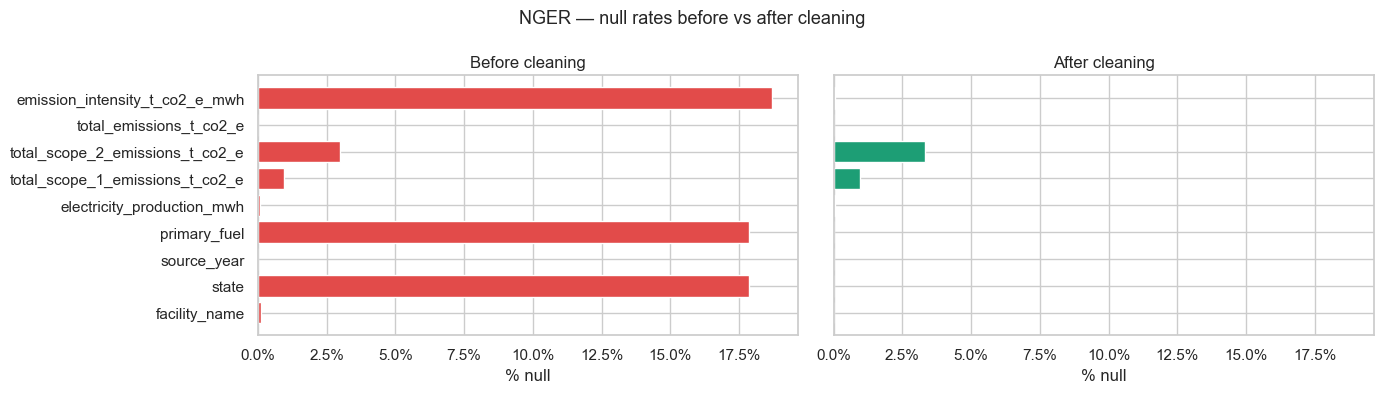

Saved: nger_null_comparison.png

NGER cleaned shape:  (4854, 16)
Years present:       [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
States present:      ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']

Null counts (key columns):
  facility_name: 0 nulls (0.0%)
  state: 0 nulls (0.0%)
  source_year: 0 nulls (0.0%)
  primary_fuel: 0 nulls (0.0%)
  electricity_production_mwh: 3 nulls (0.1%)
  total_scope_1_emissions_t_co2_e: 46 nulls (0.9%)
  total_scope_2_emissions_t_co2_e: 162 nulls (3.3%)
  total_emissions_t_co2_e: 0 nulls (0.0%)
  emission_intensity_t_co2_e_mwh: 3 nulls (0.1%)


In [11]:
sns.set_theme(style="whitegrid", palette="muted")

# Key column units for interpretability
NGER_UNITS = {
    "electricity_production_mwh":         "MWh — total net electricity sent out",
    "total_scope_1_emissions":             "t CO₂-e — direct facility emissions",
    "total_scope_2_emissions":             "t CO₂-e — indirect emissions from purchased electricity",
    "total_emissions":                     "t CO₂-e — scope 1 + scope 2",
    "emission_intensity":                  "t CO₂-e / MWh — emissions per unit electricity produced",
}
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# Save a copy of the original dataset before cleaning
nger_raw = nger_df.copy()

# -------- Step 1: Null heatmap — before cleaning and Drop fully-empty rows and columns ----------
key_cols = [
    'facility_name', 'state', 'source_year', 'primary_fuel',
    'electricity_production_mwh',
    'total_scope_1_emissions_t_co2_e',
    'total_scope_2_emissions_t_co2_e',
    'total_emissions_t_co2_e',
    'emission_intensity_t_co2_e_mwh',
]
existing_key_cols = [c for c in key_cols if c in nger_df.columns]

null_pct = nger_df[existing_key_cols].isna().mean() * 100
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(null_pct.index, null_pct.values, color='#E24B4A', edgecolor='white')
ax.set_xlabel('% null values')
ax.set_title('NGER — null rate per key column (before cleaning)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, null_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'nger_null_before.png', dpi=150)
plt.show()
print("Saved: nger_null_before.png")

# Dropping the empty rows and columns
rows_before = len(nger_df)
nger_df = nger_df.dropna(how='all')
nger_df = nger_df.dropna(axis=1, how='all')
print(f"Step 1 — dropped {rows_before - len(nger_df)} fully-empty rows")

# -------- Step 2: Strip whitespace --------
str_cols = nger_df.select_dtypes(include='object').columns
for col in str_cols:
    nger_df[col] = nger_df[col].map(lambda x: x.strip() if isinstance(x, str) else x)

# Inspect the exact characters in the remaining dash values
rows_with_dash = nger_df[nger_df['state'].str.strip() == '-']['state']
print(repr(rows_with_dash.unique()))
print([list(v.encode('utf-8')) for v in rows_with_dash.unique()])

# -------- Step 3: Standardise State column --------
STATE_NORMALISE = {
    **{v: k for k, v in STATE_TO_ABS_LABEL.items()},
    **{k: k for k in STATE_TO_ABS_LABEL.keys()},
}
if 'state' in nger_df.columns:
    state = (
        nger_df['state'].str.strip()
        .replace(r'^[-\u2013\u2014\s]+$', '', regex=True)
        .replace('', np.nan)
        .replace({'-': np.nan, '–': np.nan, '—': np.nan})
    )
nger_df['state'] = state.map(STATE_NORMALISE).fillna(state)

# -------- State distribution ---------
state_counts = nger_df['state'].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
state_counts.plot(kind='bar', ax=ax, color='#378ADD', edgecolor='white')
ax.set_title('NGER — facility records per state (all years)')
ax.set_xlabel('State')
ax.set_ylabel('Row count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'nger_state_dist.png', dpi=150)
plt.show()
print("Saved: nger_state_dist.png")

# -------- Step 4: Standardise Primary fuel + Is_renewable flag ---------
if 'primary_fuel' in nger_df.columns:
    nger_df['primary_fuel'] = nger_df['primary_fuel'].str.strip().str.title()
    nger_df['is_renewable'] = nger_df['primary_fuel'].isin(RENEWABLE_FUELS) # creates a new col

# -------- Step 5: Standardise Grid connected --------
if 'grid_connected' in nger_df.columns:
    def _norm_grid_connected(v):
        if pd.isna(v):
            return pd.NA
        if isinstance(v, (bool, np.bool_)):
            return bool(v)
        s = str(v).strip().upper()
        return {
            'ON': True,
            'OFF': False,
            'TRUE': True,
            'FALSE': False,
            'Y': True,
            'N': False,
            'YES': True,
            'NO': False,
            '1': True,
            '0': False,
        }.get(s, pd.NA)

    nger_df['grid_connected'] = nger_df['grid_connected'].map(_norm_grid_connected).astype('boolean')
    print("Grid connected value counts:")
    print(nger_df['grid_connected'].value_counts(dropna=False))

# -------- Step 6: Clipping negatives --------
# Count negatives
nger_summary = {}
for col in numeric_cols:
    if col in nger_df.columns:
        nger_count = (nger_df[col] < 0).sum()
        nger_summary[col] = nger_count
        if nger_count > 0:
            print(f"  Found {nger_count} negative values in '{col}'")

# show negative counts before clipping
if any(v > 0 for v in nger_summary.values()):
    fig, ax = plt.subplots(figsize=(9, 4))
    short_labels = [c.replace('Total ', '').replace(' t CO2 e', '').replace(' MWh','')
                    for c in nger_summary.keys()]
    ax.bar(short_labels, nger_summary.values(), color='#EF9F27', edgecolor='white')
    ax.set_title('NGER — negative values found before clipping')
    ax.set_ylabel('Count of negative rows')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig(fig_dir / 'nger_negatives.png', dpi=150)
    plt.show()
else:
    print("No negative values found — skipping the visualisation")

# Clipping negatives
for col in numeric_cols:
    if col in nger_df.columns:
        nger_df[col] = nger_df[col].clip(lower=0)
        print(f"  Clipped negatives in '{col}'")

# -------- Step 7: Derive Total emissions if missing ----------
s1 = 'total_scope_1_emissions_t_co2_e'
s2 = 'total_scope_2_emissions_t_co2_e'
tot = 'total_emissions_t_co2_e'
if tot not in nger_df.columns and s1 in nger_df.columns and s2 in nger_df.columns:
    nger_df[tot] = nger_df[s1].fillna(0) + nger_df[s2].fillna(0)

# -------- Step 8: Recalculate Emission intensity where missing --------
elec_intensity_col = 'emission_intensity_t_co2_e_mwh'
elec_prod_col = 'electricity_production_mwh'
if elec_intensity_col in nger_df.columns and elec_prod_col in nger_df.columns:
    missing_ei = nger_df[elec_intensity_col].isna() & nger_df[elec_prod_col].gt(0)
    nger_df.loc[missing_ei, elec_intensity_col] = (
        nger_df.loc[missing_ei, tot] / nger_df.loc[missing_ei, elec_prod_col]
    )

# -------- Emission intensity distribution --------
if elec_intensity_col in nger_df.columns:
    clean_ei = nger_df[elec_intensity_col].dropna()
    clean_ei = clean_ei[clean_ei < clean_ei.quantile(0.99)]  # trim extreme outliers for viz
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(clean_ei, bins=60, color='#7F77DD', edgecolor='white')
    ax.set_title('NGER — emission intensity distribution (excl. top 1% outliers)')
    ax.set_xlabel('t CO₂-e per MWh')
    ax.set_ylabel('Facility count')
    plt.tight_layout()
    plt.savefig(fig_dir / 'nger_emission_intensity_dist.png', dpi=150)
    plt.show()
    print("Saved: nger_emission_intensity_dist.png")

# -------- Step 9: Deduplicate --------
id_cols = ['facility_name', 'state', 'source_year']
existing_id_cols = [c for c in id_cols if c in nger_df.columns]
before = len(nger_df)
nger_df = nger_df.drop_duplicates(subset=existing_id_cols, keep='first')
print(f"Step 9 — deduplication removed {before - len(nger_df)} rows")

# -------- Step 10: Source_Year as integer --------
nger_df['source_year'] = pd.to_numeric(nger_df['source_year'], errors='coerce').astype('Int64')

# -------- Row count per year after deduplication --------
year_counts = nger_df['source_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
year_counts.plot(kind='bar', ax=ax, color='#1D9E75', edgecolor='white')
ax.set_title('NGER — facility records per year (after deduplication)')
ax.set_xlabel('Year')
ax.set_ylabel('Row count')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'nger_rows_per_year.png', dpi=150)
plt.show()
print("Saved: nger_rows_per_year.png")

# -------- Step 11:# Filter out corporate total and placeholder rows --------
nger_df = nger_df[
    ~nger_df['facility_name'].str.strip().str.lower().isin([
        'corporate total', '-', '', 'nan'
    ])
].copy()

print(f"Removed summary/placeholder rows. Remaining: {len(nger_df)}")

# Handle residual null facility_name / state rows
_null_rows = nger_df[nger_df["facility_name"].isna() | nger_df["state"].isna()]
if len(_null_rows) > 0:
    print(f"Dropping {len(_null_rows)} rows with null facility_name or state — cannot be linked to a facility.")
    nger_df = nger_df.dropna(subset=["facility_name", "state"]).copy()
else:
    print("No residual null facility_name/state rows.")

# -------- Null heatmap — after cleaning ----------
existing_key_cols_after = [c for c in key_cols if c in nger_df.columns]
null_pct_after = nger_df[existing_key_cols_after].isna().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, sharex=True)
axes[0].barh(null_pct.index, null_pct.values, color='#E24B4A', edgecolor='white')
axes[0].set_title('Before cleaning')
axes[0].set_xlabel('% null')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

axes[1].barh(null_pct_after.index, null_pct_after.values, color='#1D9E75', edgecolor='white')
axes[1].set_title('After cleaning')
axes[1].set_xlabel('% null')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle('NGER — null rates before vs after cleaning', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'nger_null_comparison.png', dpi=150)
plt.show()
print("Saved: nger_null_comparison.png")

# -------- Step 11: Reset index --------
nger_df = nger_df.reset_index(drop=True)

# -------- Final audit --------
print(f"\nNGER cleaned shape:  {nger_df.shape}")
print(f"Years present:       {sorted(nger_df['source_year'].dropna().unique().tolist())}")
print(f"States present:      {sorted(nger_df['state'].dropna().unique().tolist())}")
print(f"\nNull counts (key columns):")
for col in existing_key_cols_after:
    n = nger_df[col].isna().sum()
    print(f"  {col}: {n} nulls ({100*n/len(nger_df):.1f}%)")

datasets['NGER'] = nger_df


#### 2-2-2b NGER Outlier Detection


In [12]:
# --- Outlier Detection: NGER numeric columns (IQR rule) ---
NGER_NUMERIC_COLS = [
    "electricity_production_mwh",
    "total_scope_1_emissions",
    "total_scope_2_emissions",
    "total_emissions",
    "emission_intensity",
]

for col in NGER_NUMERIC_COLS:
    if col not in nger_df.columns:
        continue
    s = nger_df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    flag_col = f"is_outlier_{col}"
    nger_df[flag_col] = (nger_df[col] < lower) | (nger_df[col] > upper)
    n_flagged = int(nger_df[flag_col].sum())
    print(f"  {col}: {n_flagged} outliers flagged  [IQR bounds: {lower:.1f}, {upper:.1f}]")

print(f"\nStrategy: outlier rows retained and flagged only.")
print("  Extreme values are plausible for large fossil-fuel facilities (e.g. high scope-1 emitters).")
print("  Removal would bias state-level aggregates; use is_outlier_* flags to filter where needed.")
datasets['NGER'] = nger_df


  electricity_production_mwh: 513 outliers flagged  [IQR bounds: -337096.2, 570325.8]

Strategy: outlier rows retained and flagged only.
  Extreme values are plausible for large fossil-fuel facilities (e.g. high scope-1 emitters).
  Removal would bias state-level aggregates; use is_outlier_* flags to filter where needed.


#### 2-2-3 Cleaning ECON

In [13]:
# -----------------------------
# 1) Load raw data
# -----------------------------
edf = econ_df.copy()

# -----------------------------
# 2) Basic cleaning
# -----------------------------

edf = edf.dropna(subset=["code", "year"]).copy()  # minimum identity fields - drop rows missing code or year
edf["code"] = edf["code"].astype("string").str.strip()
geo_info["code"] = geo_info["code"].astype("string").str.strip()
edf["year"] = pd.to_numeric(edf["year"], errors="coerce")
edf = edf[edf["year"].between(2014, 2024)].copy()
# Note: ABS 2011-24 release contains 2011, 2016-2024 only.
# Years 2014-2015 are structurally absent from this release, not filtered out due to quality.

# -----------------------------
# 3) Geography standardisation
# -----------------------------

# Each ABS geographic code is classified into its corresponding ASGS level
# (national, state/territory, GCCSA, SA4, LGA, SA3, or SA2) by inspecting the
# length and pattern of the code string, since the ABS assigns distinct
# code formats to each geographic level.

geo_info = geo_info.dropna(subset=['code']).copy() # drop rows with missing code; .copy() prevents SettingWithCopyWarning
c = geo_info["code"].astype(str).str.strip() # ensure code is string and strip whitespace for accurate length and pattern checks
n = c.str.len() # length of code string, used to determine ASGS level
is_num = c.str.isdigit() # check if code is numeric, used for several ASGS levels that have numeric codes
# t2 is a boolean flag that identifies whether a code comes from Table 2 (LGA data) or Table 1 (SA3 data).
# It's needed because both LGAs and SA3s have 5-digit numeric codes — so code length alone can't distinguish them.
# The only way to tell them apart is by checking which table they came from:
# So t2 = True means the code is from Table 2 → classify as LGA, t2 = False means Table 1 → classify as SA3
t2 = geo_info.groupby('code')['source_table'].transform(lambda x: (x == 'Table 2').all()) # check if all source_table entries for this code are 'Table 2', used to distinguish SA3 vs LGA for 5-digit numeric codes
t2 = t2.fillna(False).astype(bool) # fill NA with False for codes that only appear in Table 1 or have missing source_table, ensuring they are not misclassified as SA3
is_gccsa = (n == 5) & c.str.match(r"^\d[A-Za-z]{4}$", na=False) # check for GCCSA codes which are 5 characters long, start with a digit followed by 4 letters (e.g. '1RCH'), used to classify GCCSA level

geo_info["asgs_level"] = np.select(
    [
        (c == "AUS").values, # national level code is 'AUS'
        ((n == 1) & is_num & (c != "0")).values, # state/territory level codes are single-digit numeric (1-8) excluding '0'
        (is_gccsa).values, # GCCSA level codes are 5-character alphanumeric starting with a digit followed by 4 letters
        ((n == 3) & is_num).values, # SA4 level codes are 3-digit numeric
        ((n == 5) & is_num & t2).values, # LGA level codes are 5-digit numeric that appear only in Table 2 (t2=True)
        ((n == 5) & is_num & (~t2)).values, # SA3 level codes are 5-digit numeric that do not appear only in Table 2 (t2=False)
        ((n == 9) & is_num).values, # SA2 level codes are 9-digit numeric
    ],
    [
        "national",
        "state_territory",
        "gccsa",
        "sa4",
        "lga",
        "sa3",
        "sa2",
    ],
    default="unknown",
)

geo_info = geo_info.drop(columns=["_t2"], errors="ignore").copy() # drop temporary t2 column used for ASGS level classification


# -----------------------------
# 4) Remove low-quality data
# -----------------------------
# Drop rows missing in **more than 2** of the seven headline indicator columns (those present in edf).

ECON_CLEAN_CTX = {}  # pre-quality snapshot + abort mask for the post-clean summary cell
ECON_CLEAN_CTX["pre_abort"] = edf.copy() #. save copy of edf before dropping low-quality rows, for later comparison and audit

# manually select most important indicators
# represent key economic dimensions of interest, and are commonly used in analysis and reporting.
ECON_QUALITY_KEY_COLS = [
    "total_number_of_businesses", # represents the count of active businesses in the region, indicating economic activity and business density.
    "agriculture,_forestry_and_fishing_(no.)", # represents the number of businesses in the agriculture, forestry, and fishing sector, which is a key part of the economy in many regions and can indicate the health of primary industries.
    "electricity,_gas,_water_and_waste_services_(no.)", # represents the number of businesses in the utilities sector, which is essential for infrastructure and can indicate the level of development and service provision in the region.
    "value_of_total_building_($m)", # represents the total value of building work done in the region, indicating construction activity and investment in infrastructure.
    "area_of_holding_-_total_area_(ha)", # represents the total area of agricultural holdings, indicating the scale of agricultural operations.
    "agricultural_production_-_total_gross_value_($m)", # represents the total gross value of agricultural production, indicating the economic contribution of agriculture.
    "total_persons_employed_aged_15_years_and_over_(no.)", # represents the total number of employed persons aged 15 and over, indicating the labor force size and employment levels.
]
# Check which of these key columns are actually present in the dataset, as some may be missing due to changes in ABS reporting or issues with data loading.
_keys = [c for c in ECON_QUALITY_KEY_COLS if c in edf.columns]
if len(_keys) < len(ECON_QUALITY_KEY_COLS):
    print("WARN: some key columns not in edf:", sorted(set(ECON_QUALITY_KEY_COLS) - set(_keys)))

# If key columns are present, drop rows that have more than 2 missing values among these key columns, as they are likely to be of low quality and could skew analysis.
# We allow up to 2 missing values to retain some data while still ensuring a reasonable level of completeness.
if _keys:
    is_t2 = edf["source_table"].eq("Table 2")
    _missing_per_row = edf[_keys].isna().sum(axis=1)
    _keep = _missing_per_row <= 2 # key rows with 5 out of 7 key indicators - we choose such a threshold
    ECON_CLEAN_CTX["abort_mask"] = ~_keep # save the mask of dropped rows for later audit and comparison
    _n_drop = int((~_keep).sum())
    edf = edf.loc[_keep].copy()
    print(
        f"Dropped {_n_drop} rows with >2 missing values among the {len(_keys)} headline key columns."
    )
    # Provide a breakdown of the dropped rows by source table (Table 1 vs Table 2) to understand which geographic levels were more affected by the quality filtering.
    for label, mask in (("Table 1", ~is_t2), ("Table 2", is_t2)):
        sub = mask.sum()
        if int(sub) == 0:
            continue
        dr = float((~_keep & mask).sum()) / float(sub) * 100.0
        print(f"  {label}: rows={int(sub)}, dropped%={dr:.1f}")
else:
    print("WARN: none of ECON_QUALITY_KEY_COLS found on edf; skip row drop.")
    ECON_CLEAN_CTX["abort_mask"] = pd.Series(False, index=ECON_CLEAN_CTX["pre_abort"].index)

# -----------------------------
# 5) Sumcheck (published total vs sum of components)
# -----------------------------
# Several ABS columns are headline totals that should match the sum of sibling breakdown columns.
# We only report mismatches; rows where any field is missing after coercion are skipped.

# integrity checks to verify whether ABS totals match the sum of their components

def _econ_run_sumchecks(df, check_list, rtol=1e-5, atol=0.51):
    for _label, _total, _parts in check_list:
        _need = [_total, *_parts]
        _miss = [c for c in _need if c not in df.columns]
        if _miss:
            print("SUMCHECK skip (" + _label + "): missing", _miss)
            continue
        _sub = df[_need].apply(pd.to_numeric, errors="coerce")
        _all_finite = _sub.notna().all(axis=1)
        _sum_parts = _sub[_parts].sum(axis=1)
        _totv = _sub[_total]
        _match = np.isclose(_totv, _sum_parts, rtol=rtol, atol=atol, equal_nan=False)
        _bad = _all_finite & ~_match
        _n_bad = int(_bad.sum())
        _n_cmp = int(_all_finite.sum())
        if _n_cmp == 0:
            print("SUMCHECK (" + _label + "): no rows with all fields non-null")
            continue
        if _n_bad == 0:
            print(
                "SUMCHECK OK (" + _label + "): " + str(_n_cmp) + " comparable rows within atol="
                + str(atol) + ", rtol=" + str(rtol)
            )
            continue
        _delta = (_totv - _sum_parts).abs().loc[_bad]
        print(
            "SUMCHECK WARN (" + _label + "): " + str(_n_bad) + " / " + str(_n_cmp)
            + " rows exceed tolerance; max |total - sum(parts)| = " + str(float(_delta.max()))
        )


_econ_run_sumchecks(edf, econ_sum_checks)

# Flag rows with sumcheck discrepancies so downstream users can filter them
edf['is_sumcheck_warn'] = False
_biz_size_cols = [c for c in edf.columns if 'employing' in c.lower()]
if _biz_size_cols and 'total_number_of_businesses' in edf.columns:
    _anchor = pd.to_numeric(edf['total_number_of_businesses'], errors='coerce')
    _sub_sum = edf[_biz_size_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)
    _diff = (_anchor - _sub_sum).abs()
    edf.loc[_diff > 1, 'is_sumcheck_warn'] = True
    print(f"is_sumcheck_warn: {edf['is_sumcheck_warn'].sum()} rows flagged with sumcheck discrepancy")

# -----------------------------
# 6) Remove duplicates
# -----------------------------
edf = edf.sort_values(["code", "year"]) # these 2 variables are the most relevant for identifying duplicates in the context of this dataset
edf = edf.drop_duplicates(subset=["code", "year"], keep="first").reset_index(drop=True)

# -----------------------------
# 7) Add 0 to frequent zero columns after cleaning
# -----------------------------
# When an "anchor" field is present, ABS often leaves sibling breakdowns as '-' → NaN after coercion.
# Treat those missing siblings as numeric zero for rows where the anchor is non-null.

# This function fills NaN values with 0 in specified target columns when a certain anchor column is present and non-null.
def _econ_anchor_zero_fill(df, anchor, targets):
    if anchor not in df.columns:
        return df
    cols = [c for c in targets if c in df.columns]
    if not cols:
        return df
    row_on = df[anchor].notna()
    for c in cols:
        m = row_on & df[c].isna()
        if m.any():
            df.loc[m, c] = 0
    return df


_econ_anchor_zero_fill(
    edf,
    "total_dwellings_(no.)",
    [
        "houses_-_removals_(no.)","houses_-_total_(no.)","townhouses_-_additions_(no.)","townhouses_-_removals_(no.)"
        ,"townhouses_-_total_(no.)","apartments_-_additions_(no.)","apartments_-_removals_(no.)","apartments_-_total_(no.)"
        ,"total_dwelling_additions_(no.)","total_dwelling_removals_(no.)","total_dwellings_(no.)",
        "total_dwelling_removals_(no.)","houses_-_additions_(no.)",
    ],

)
_econ_anchor_zero_fill(
    edf,
    "total_persons_employed_aged_15_years_and_over_(no.)",
    [
        "agriculture,_forestry_and_fishing_(%)","mining_(%)","manufacturing_(%)","electricity,_gas,_water_and_waste_services_(%)","construction_(%)","wholesale_trade_(%)","retail_trade_(%)","accommodation_and_food_services_(%)","transport,_postal_and_warehousing_(%)","information_media_and_telecommunications_(%)","financial_and_insurance_services_(%)","rental,_hiring_and_real_estate_services_(%)","professional,_scientific_and_technical_services_(%)","administrative_and_support_services_(%)","public_administration_and_safety_(%)","education_and_training_(%)","health_care_and_social_assistance_(%)","arts_and_recreation_services_(%)","other_services_(%)","industry_of_employment_inadequately_described_or_not_stated_(%)",
        "transport,_postal_and_warehousing_(%)","information_media_and_telecommunications_(%)","financial_and_insurance_services_(%)","rental,_hiring_and_real_estate_services_(%)","professional,_scientific_and_technical_services_(%)","administrative_and_support_services_(%)","public_administration_and_safety_(%)","education_and_training_(%)","health_care_and_social_assistance_(%)","arts_and_recreation_services_(%)","other_services_(%)","industry_of_employment_inadequately_described_or_not_stated_(%)",
        "health_care_and_social_assistance_(%)", "arts_and_recreation_services_(%)","other_services_(%)","industry_of_employment_inadequately_described_or_not_stated_(%)",
    ],
)
_econ_anchor_zero_fill(
    edf,
    "area_of_holding_-_total_area_(ha)",
    [
        "dairy_cattle_-_total_(no.)", "meat_cattle_-_total_(no.)",
        "sheep_and_lambs_-_total_(no.)", "pigs_-_total_(no.)", "meat_chickens_-_total_(no.)",
        "broadacre_crops_-_total_area_(ha)", "vegetables_-_total_area_(ha)", "orchard_fruit_trees_and_nut_trees_(produce_intended_for_sale)_-_total_area_-_(ha)"
    ],
)

# Zero fill summary
print('Anchor-based zero imputation applied: breakdown nulls filled with 0 where anchor total was non-null.')

datasets["ECON"] = edf
display(edf.head())


Dropped 28363 rows with >2 missing values among the 7 headline key columns.
  Table 1: rows=26181, dropped%=91.5
  Table 2: rows=4923, dropped%=89.6
SUMCHECK WARN (total_number_of_businesses vs size bands): 64 / 2627 rows exceed tolerance; max |total - sum(parts)| = 2.0
SUMCHECK WARN (total_number_of_business_entries vs components): 269 / 656 rows exceed tolerance; max |total - sum(parts)| = 4.0
SUMCHECK WARN (total_number_of_business_exits vs components): 292 / 815 rows exceed tolerance; max |total - sum(parts)| = 6.0
SUMCHECK WARN (total_dwellings_(no.) vs dwelling-type totals): 1354 / 2072 rows exceed tolerance; max |total - sum(parts)| = 18127.0
SUMCHECK WARN (total_dwelling_additions_(no.) vs additions by type): 45 / 668 rows exceed tolerance; max |total - sum(parts)| = 36.0
SUMCHECK OK (total_dwelling_removals_(no.) vs removals by type): 99 comparable rows within atol=0.51, rtol=1e-05
is_sumcheck_warn: 2732 rows flagged with sumcheck discrepancy
Anchor-based zero imputation appli

,code,year,number_of_non-employing_businesses,number_of_employing_businesses:_1-4_employees,number_of_employing_businesses:_5-19_employees,number_of_employing_businesses:_20_or_more_employees,total_number_of_businesses,number_of_non-employing_business_entries,number_of_employing_business_entries:_1-4_employees,number_of_employing_business_entries:_5-19_employees,number_of_employing_business_entries:_20_or_more_employees,total_number_of_business_entries,number_of_non-employing_business_exits,number_of_employing_business_exits:_1-4_employees,number_of_employing_business_exits:_5-19_employees,number_of_employing_business_exits:_20_or_more_employees,total_number_of_business_exits,"agriculture,_forestry_and_fishing_(no.)",mining_(no.),manufacturing_(no.),"electricity,_gas,_water_and_waste_services_(no.)",construction_(no.),wholesale_trade_(no.),retail_trade_(no.),accommodation_and_food_services_(no.),...,financial_and_insurance_services_(%),"rental,_hiring_and_real_estate_services_(%)","professional,_scientific_and_technical_services_(%)",administrative_and_support_services_(%),public_administration_and_safety_(%),education_and_training_(%),health_care_and_social_assistance_(%),arts_and_recreation_services_(%),other_services_(%),industry_of_employment_inadequately_described_or_not_stated_(%),total_persons_employed_aged_15_years_and_over_(no.),houses_-_additions_(no.),houses_-_removals_(no.),houses_-_total_(no.),townhouses_-_additions_(no.),townhouses_-_removals_(no.),townhouses_-_total_(no.),apartments_-_additions_(no.),apartments_-_removals_(no.),apartments_-_total_(no.),total_dwelling_additions_(no.),total_dwelling_removals_(no.),total_dwellings_(no.),source_table,is_sumcheck_warn
0,1,2021.0,457432.0,267680.0,72797.0,19694.0,817603.0,85411.0,39860.0,2598.0,382.0,128251.0,77065.0,16135.0,2659.0,585.0,96444.0,52802.0,1569.0,27530.0,2606.0,138030.0,29366.0,49149.0,36151.0,...,5.3,1.7,8.9,3.2,6.1,8.7,14.4,1.4,3.4,4.6,3684158.0,23993.0,6678.0,2144705.0,8233.0,79.0,398156.0,20325.0,300.0,784821.0,52559.0,7057.0,3336762.0,Table 1,True
1,10050,2021.0,2615.0,1393.0,569.0,134.0,4711.0,395.0,218.0,18.0,NaN,633.0,341.0,55.0,17.0,NaN,415.0,249.0,3.0,188.0,137.0,894.0,148.0,275.0,242.0,...,1.6,1.3,4.2,3.0,7.0,10.1,18.2,1.0,3.7,3.9,26344.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Table 2,True
2,101,2021.0,12048.0,7187.0,2419.0,424.0,22078.0,1814.0,821.0,72.0,9.0,2716.0,1619.0,359.0,86.0,15.0,2079.0,5083.0,55.0,760.0,78.0,4566.0,458.0,1275.0,1228.0,...,1.2,1.3,5.7,3.0,14.7,7.8,12.2,1.7,3.6,3.8,111423.0,725.0,37.0,96202.0,182.0,0.0,10670.0,17.0,38.0,8487.0,924.0,75.0,115624.0,Table 1,True
3,10102,2021.0,2830.0,1693.0,525.0,110.0,5158.0,500.0,259.0,15.0,4.0,778.0,489.0,104.0,19.0,6.0,618.0,646.0,12.0,221.0,24.0,1288.0,111.0,245.0,191.0,...,1.1,1.4,7.8,2.6,26.1,7.3,9.7,1.4,3.5,3.5,35548.0,129.0,7.0,20075.0,48.0,0.0,3755.0,7.0,38.0,3254.0,184.0,45.0,27134.0,Table 1,True
4,101021007,2021.0,456.0,183.0,47.0,NaN,688.0,65.0,21.0,3.0,NaN,87.0,47.0,9.0,NaN,3.0,59.0,293.0,3.0,20.0,4.0,83.0,13.0,37.0,31.0,...,1.2,1.3,6.0,2.5,12.0,8.2,7.6,1.5,3.1,4.1,2013.0,16.0,0.0,2563.0,26.0,0.0,85.0,1.0,0.0,15.0,43.0,0.0,2678.0,Table 1,True


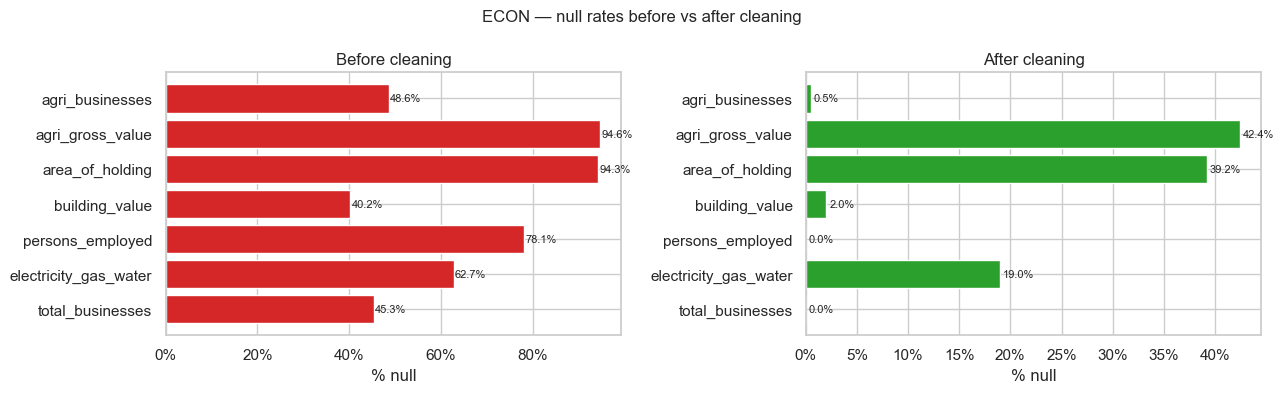

Saved: econ_null_before_after.png


In [14]:
# ── ECON — null rates before vs after cleaning ──────────────────────────────

ECON_VIZ_COLS = [
    "total_number_of_businesses",
    "electricity,_gas,_water_and_waste_services_(no.)",
    "total_persons_employed_aged_15_years_and_over_(no.)",
    "value_of_total_building_($m)",
    "area_of_holding_-_total_area_(ha)",
    "agricultural_production_-_total_gross_value_($m)",
    "agriculture,_forestry_and_fishing_(no.)",
]

# compute null rates before and after cleaning
pre  = ECON_CLEAN_CTX["pre_abort"]
post = datasets["ECON"]

pre_cols  = [c for c in ECON_VIZ_COLS if c in pre.columns]
post_cols = [c for c in ECON_VIZ_COLS if c in post.columns]

null_before = pre[pre_cols].isna().mean() * 100
null_after  = post[post_cols].isna().mean() * 100

# short display labels
short_labels = {
    "total_number_of_businesses": "total_businesses",
    "electricity,_gas,_water_and_waste_services_(no.)":"electricity_gas_water",
    "total_persons_employed_aged_15_years_and_over_(no.)": "persons_employed",
    "value_of_total_building_($m)": "building_value",
    "area_of_holding_-_total_area_(ha)": "area_of_holding",
    "agricultural_production_-_total_gross_value_($m)": "agri_gross_value",
    "agriculture,_forestry_and_fishing_(no.)": "agri_businesses",
}

labels_b = [short_labels.get(c, c) for c in pre_cols]
labels_a = [short_labels.get(c, c) for c in post_cols]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle("ECON — null rates before vs after cleaning", fontsize=12)

# before
ax1.barh(labels_b, null_before.values, color="#d62728")
ax1.set_xlabel("% null")
ax1.set_title("Before cleaning")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for i, v in enumerate(null_before.values):
    ax1.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

# after
ax2.barh(labels_a, null_after.values, color="#2ca02c")
ax2.set_xlabel("% null")
ax2.set_title("After cleaning")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for i, v in enumerate(null_after.values):
    ax2.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("figures/econ_null_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: econ_null_before_after.png")

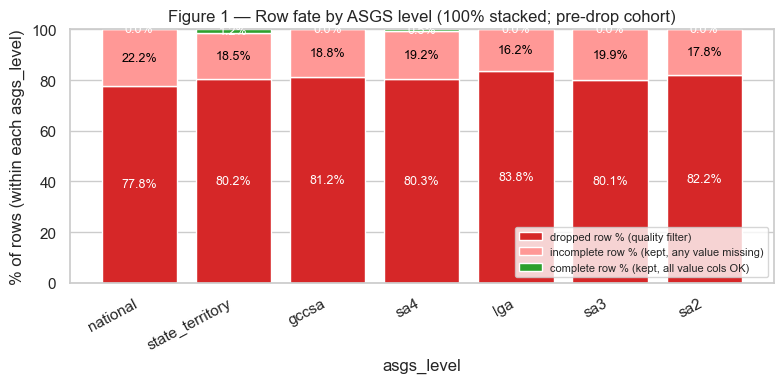

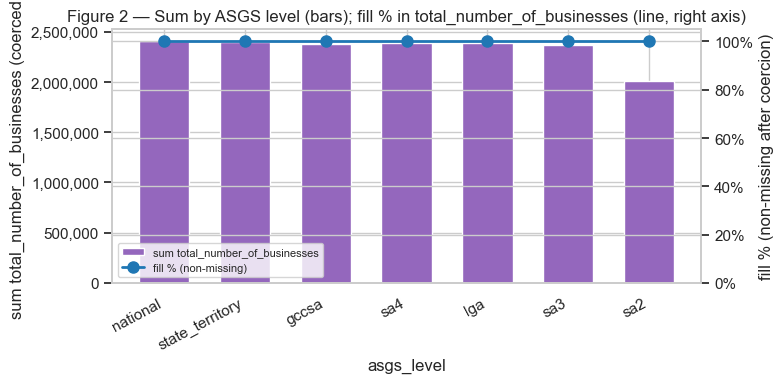

In [15]:
# ECON — Figures 1 & 2 (run after §2-2-3 cleaning). Needs `ECON_CLEAN_CTX`; merges `geo_info` only if `asgs_level` is missing.

LEVEL_ORDER = (
    "national",
    "state_territory",
    "gccsa",
    "sa4",
    "lga",
    "sa3",
    "sa2"
)
_LO = set(LEVEL_ORDER)
_TOTAL_BUS = "total_number_of_businesses"


def _value_any_na(df):
    text_cols = df.iloc[:, [0]]
    num_cols = df.iloc[:, 1:]
    num_na = num_cols.isna().any(axis=1)

    placeholders = r"^(|--|\.\.|N/A|n/a|np|NP|-)$"
    text_na = text_cols.iloc[:, 0].astype(str).str.strip().str.match(placeholders, na=True)

    return num_na | text_na

def _coerce_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    t = s.astype("string").str.strip().replace(["", "-", "..", "N/A", "n/a"], pd.NA)
    return pd.to_numeric(t, errors="coerce")

##################### figure 1

# add column identifying row status
pre_econ = ECON_CLEAN_CTX["pre_abort"].merge(geo_info[["code", "asgs_level"]], on="code", how="inner")
pre_econ["dropped"] = ECON_CLEAN_CTX["abort_mask"].reindex(pre_econ.index).fillna(False).astype(bool)

_proc = datasets["ECON"]
_any_pre = _value_any_na(pre_econ)
_lookup = _proc.assign(any_value_na=_value_any_na(_proc))[["code", "year", "any_value_na"]]
pre_econ = pre_econ.merge(_lookup, on=["code", "year"], how="left")
pre_econ["any_value_na"] = pre_econ["any_value_na"].where(~pre_econ["dropped"], False)
pre_econ["any_value_na"] = pre_econ["any_value_na"].fillna(_any_pre).astype(bool)


# Calculate the raw stats using groupby
econ_stats = pre_econ.groupby("asgs_level").apply(lambda sub: pd.Series({
    "v_drop": 100.0 * sub["dropped"].mean(),
    "v_inc":  100.0 * (~sub["dropped"] & sub["any_value_na"]).mean(),
    "v_comp": 100.0 * (~sub["dropped"] & ~sub["any_value_na"]).mean()
})).reset_index()

# Reorder to match your specific LEVEL_ORDER
econ_stats["asgs_level"] = pd.Categorical(econ_stats["asgs_level"], categories=LEVEL_ORDER, ordered=True)
econ_stats = econ_stats.sort_values("asgs_level")

#
v_drop = econ_stats["v_drop"]
v_inc = econ_stats["v_inc"]
v_comp = econ_stats["v_comp"]
x = np.arange(len(econ_stats["asgs_level"]))
#b = np.array(v_drop) + np.array(v_inc)

fig1, ax1 = plt.subplots(figsize=(8, 4))
bar_d = ax1.bar(x, v_drop, label="dropped row % (quality filter)", color="#d62728")
bar_i = ax1.bar(x, v_inc, bottom=v_drop, label="incomplete row % (kept, any value missing)", color="#ff9896")
b = np.array(v_drop) + np.array(v_inc)
bar_c = ax1.bar(x, v_comp, bottom=b, label="complete row % (kept, all value cols OK)", color="#2ca02c")
ax1.bar_label(bar_d, fmt='%.1f%%', label_type='center', color='white', fontsize=9)
ax1.bar_label(bar_i, fmt='%.1f%%', label_type='center', color='black', fontsize=9)
ax1.bar_label(bar_c, fmt='%.1f%%', label_type='center', color='white', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(econ_stats["asgs_level"], rotation=28, ha="right")
ax1.set_ylim(0, 100)
ax1.set_ylabel("% of rows (within each asgs_level)")
ax1.set_xlabel("asgs_level")
ax1.set_title("Figure 1 — Row fate by ASGS level (100% stacked; pre-drop cohort)")
ax1.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("figures/econ_fig1_asgs_row_fate_pct.png", dpi=150, bbox_inches="tight")
plt.show()

##################### figure 2

_rep = edf.merge(geo_info, on="code", how="inner")
_tb = _coerce_series(_rep[_TOTAL_BUS])
u2 = set(_rep["asgs_level"].dropna())
lv2 = [x for x in LEVEL_ORDER if x in u2] + sorted(u2 - _LO)
_r2 = _rep.assign(_tb=_tb)
sums = _r2.groupby("asgs_level", observed=True)["_tb"].sum().reindex(lv2)
fill_pct = (
    _r2.groupby("asgs_level", observed=True)["_tb"]
    .agg(lambda s: 100.0 * float(s.notna().mean()))
    .reindex(lv2)
)

x2 = np.arange(len(lv2))
fig2, axb = plt.subplots(figsize=(8,4))
axb.bar(x2, sums.values, color="#9467bd", width=0.62, label="sum " + _TOTAL_BUS)
axb.set_xticks(x2)
axb.set_xticklabels(lv2, rotation=28, ha="right")
axb.set_xlabel("asgs_level")
axb.set_ylabel("sum " + _TOTAL_BUS + " (coerced)")
axb.set_title(
    "Figure 2 — Sum by ASGS level (bars); fill % in " + _TOTAL_BUS + " (line, right axis)"
)
axb.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

axr = axb.twinx()
axr.plot(x2, fill_pct.values, "o-", color="#1f77b4", linewidth=2.0, markersize=8, label="fill % (non-missing)")
axr.set_ylabel("fill % (non-missing after coercion)")
axr.set_ylim(0, 105)
axr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

h1, l1 = axb.get_legend_handles_labels()
h2, l2 = axr.get_legend_handles_labels()
axb.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig("figures/econ_fig2_asgs_businesses_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


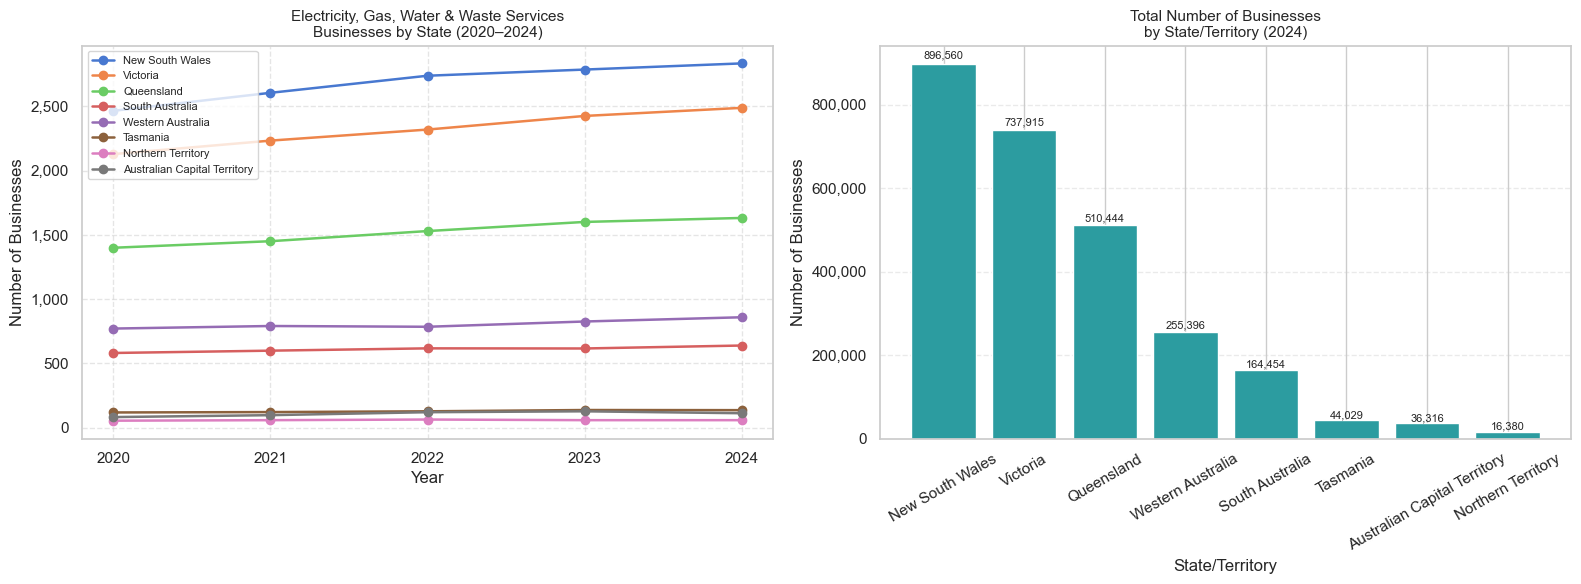

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- shared state mapping ---
DIGIT_TO_STATE = {1: "NSW", 2: "VIC", 3: "QLD", 4: "SA", 5: "WA", 6: "TAS", 7: "NT", 8: "ACT"}

plot_df = econ_df.copy()
plot_df["State_Key"] = pd.to_numeric(plot_df["code"], errors="coerce").map(DIGIT_TO_STATE)
plot_df = plot_df[plot_df["State_Key"].isin(STATE_TO_ABS_LABEL.keys())].copy()
plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce").astype("Int64")

# --- Figure 1: line chart — electricity sector businesses by state over time ---
egww_col = "electricity,_gas,_water_and_waste_services_(no.)"
plot_line = plot_df[plot_df[egww_col].notna() & plot_df["year"].notna()].copy()
plot_line = plot_line.groupby(["State_Key", "year"], as_index=False)[egww_col].sum(min_count=1)

for sc, lbl in STATE_TO_ABS_LABEL.items():
    sd = plot_line[plot_line["State_Key"] == sc].sort_values("year")
    if sd.empty:
        continue
    ax1.plot(sd["year"], sd[egww_col], marker="o", label=lbl, linewidth=1.8)

ax1.set_title("Electricity, Gas, Water & Waste Services\nBusinesses by State (2020–2024)", fontsize=11)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Businesses")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Figure 2: bar chart — total businesses per state (latest year only: 2024) ---
total_col = "total_number_of_businesses"
plot_bar = plot_df[
    plot_df[total_col].notna()
    & (plot_df["year"] == 2024)
].copy()
plot_bar = plot_bar.groupby("State_Key", as_index=False)[total_col].sum()
plot_bar = plot_bar.sort_values(total_col, ascending=False)
plot_bar["Label"] = plot_bar["State_Key"].map(STATE_TO_ABS_LABEL)

bars = ax2.bar(plot_bar["Label"], plot_bar[total_col], color="#2c9ca0", edgecolor="white")
ax2.set_title("Total Number of Businesses\nby State/Territory (2024)", fontsize=11)
ax2.set_xlabel("State/Territory")
ax2.set_ylabel("Number of Businesses")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.tick_params(axis="x", rotation=30)
ax2.grid(True, axis="y", linestyle="--", alpha=0.4)
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=8
    )

plt.tight_layout()
plt.savefig(fig_dir / "econ_businesses_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2-2-4 ECON Geographic Code Validation


In [17]:
#### 2-2-4 ECON Geographic Code Validation
# Cross-check ECON region codes against the ASGS reference loaded in 1-3.
# Rows whose code does not appear in any ASGS layer are dropped (inner join).

if raw_geo_layers:
    _asgs_ref  = pd.concat(
        [gdf[["layer", "code", "geo_name"]] for gdf in raw_geo_layers.values()],
        ignore_index=True
    )
    _valid_codes = set(_asgs_ref["code"])

    _edf = econ_df.copy()
    _edf["code"] = _edf["code"].astype(str).str.strip()
    _econ_codes  = set(_edf["code"].dropna())
    _matched     = _econ_codes & _valid_codes
    _unmatched   = _econ_codes - _valid_codes

    print(f"ECON codes total:    {len(_econ_codes)}")
    print(f"Matched in ASGS:     {len(_matched)} ({100*len(_matched)/max(len(_econ_codes),1):.1f}%)")
    print(f"Unmatched (dropped): {len(_unmatched)}")
    if _unmatched:
        _lv = _edf[_edf["code"].isin(_unmatched)]["asgs_level"].value_counts() if "asgs_level" in _edf.columns else pd.Series({"(unknown)": len(_unmatched)})
        print("Unmatched by ASGS level:")
        print(_lv.to_string())

    # Keep only rows with a valid ASGS code
    econ_df = _edf[_edf["code"].isin(_valid_codes)].copy()
    datasets["ECON"] = econ_df
    print(f"\nECON rows after filtering to valid ASGS codes: {len(econ_df)}")
else:
    print("SKIP: raw_geo_layers not loaded.")


ECON codes total:    3460
Matched in ASGS:     3453 (99.8%)
Unmatched (dropped): 7
Unmatched by ASGS level:
(unknown)    7

ECON rows after filtering to valid ASGS codes: 34530


#### 2-2-5 Cleaning LGCS

In [18]:
lgcs_df = datasets['LGCS'].copy()

# -----------------------------
# 1) Strip whitespace from string columns
# -----------------------------
# No whitespace issues found but applied defensively for robustness
for col in lgcs_df.select_dtypes(include='object').columns:
    lgcs_df[col] = lgcs_df[col].str.strip()

# -----------------------------
# 2) Convert data types
# -----------------------------
# convert date columns to YYYY-MM-DD format to match SQL date format
lgcs_df['accreditation_start_date'] = pd.to_datetime(lgcs_df['accreditation_start_date'], dayfirst=True, errors='coerce')
lgcs_df['approval_date'] = pd.to_datetime(lgcs_df['approval_date'], dayfirst=True, errors='coerce')
lgcs_df['postcode'] = lgcs_df['postcode'].astype('string') # preserve leading zeros

# -----------------------------
# 4) Remove duplicates
# -----------------------------
# Accreditation code is the unique identifier for each power station - need to make sure that there are no duplicates
lgcs_df = lgcs_df.drop_duplicates(subset=['accreditation_code'], keep='first').reset_index(drop=True)

# -----------------------------
# 5) Final validation
# -----------------------------
print("LGCS shape:", lgcs_df.shape)
print("Remaining NaNs:", lgcs_df.isna().sum().sum())

datasets['LGCS'] = lgcs_df
display(lgcs_df.head())


LGCS shape: (57, 8)
Remaining NaNs: 0


,accreditation_code,power_station_name,state,postcode,installed_capacity_(mw),fuel_source(s),accreditation_start_date,approval_date
0,SRPXQLO8,DONS FORT - SOLAR W SGU - QLD,QLD,4660,0.421,Solar,2025-10-21,2026-01-06
1,SRPYNSK0,Mintus Coles - Solar w SGU- NSW,NSW,2153,0.190,Solar,2025-12-09,2026-01-06
2,SRPXQLP1,Ventora - Acacia Ridge - Solar - QLD,QLD,4110,0.162,Solar,2025-11-17,2026-01-06
3,SRPYNSK3,Bayside Aged Care - Solar - Morisset - NSW,NSW,2264,0.140,Solar,2025-12-16,2026-01-08
4,SRPVWAQ0,Matrix Composites and Engineering Pty Ltd - So...,WA,6166,0.850,Solar,2025-12-17,2026-01-08


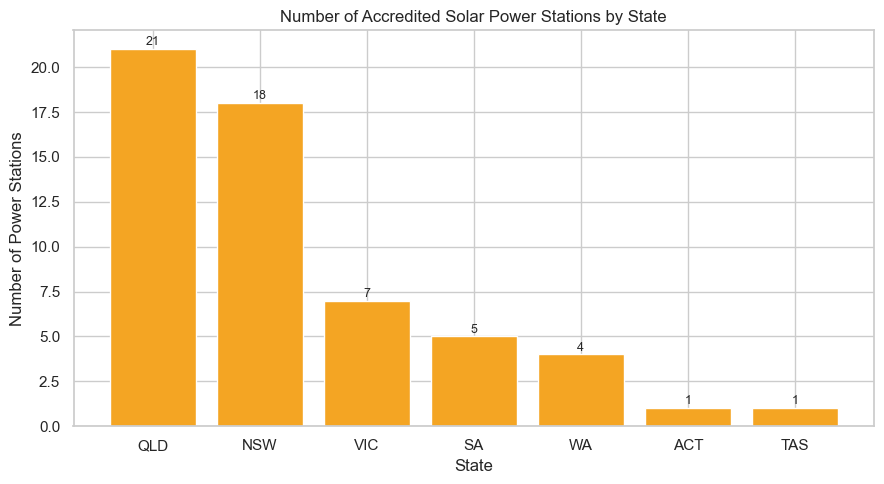

In [19]:
count_by_state = lgcs_df.groupby('state')['accreditation_code'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(count_by_state.index, count_by_state.values, color='#F4A523', edgecolor='white')

ax.set_title('Number of Accredited Solar Power Stations by State', fontsize=12)
ax.set_xlabel('State')
ax.set_ylabel('Number of Power Stations')

for bar, val in zip(bars, count_by_state.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{int(val)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/lgcs_stations_by_state.png', dpi=150, bbox_inches='tight')
plt.show()


### 2-3 Data Exploration Visualisations

Map of all geocoded NGER facilities and LGCS power stations, and key emission/electricity metrics by state.


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1113560075.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/1113560075.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(fig_dir / "nger_state_metrics.png", dpi=150, bbox_inches="tight")
/Users/chingyu/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


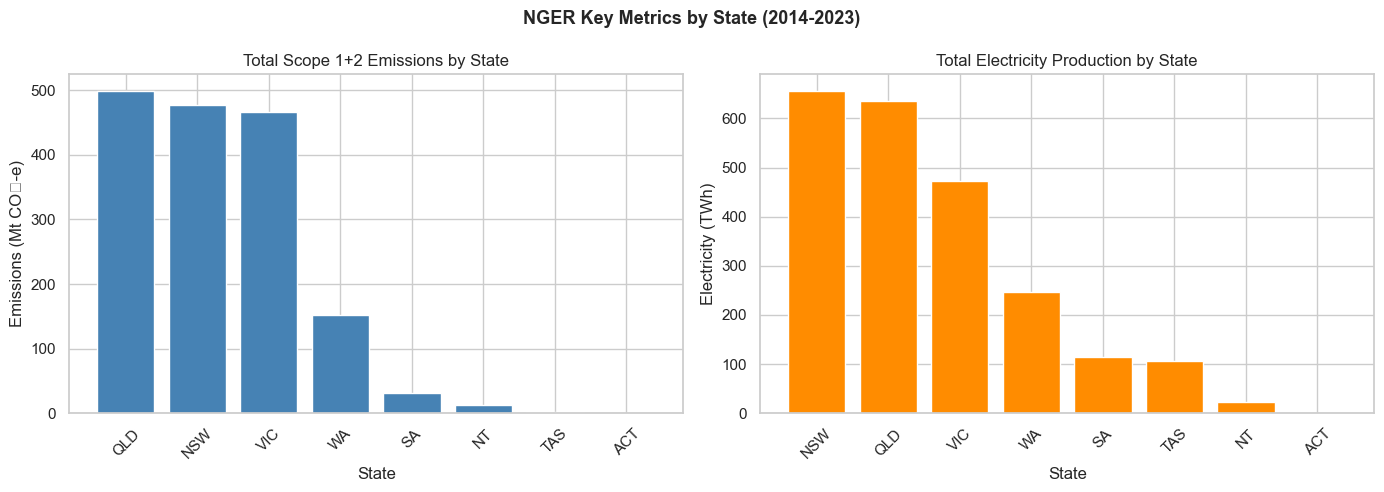

Saved: nger_state_metrics.png


In [20]:
# --- Figure: Key NGER metrics by state ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_df = datasets.get("NGER", nger_df) if "datasets" in dir() else nger_df

if "state" in _df.columns and "total_emissions_t_co2_e" in _df.columns:
    _em = _df.groupby("state")["total_emissions_t_co2_e"].sum().sort_values(ascending=False)
    axes[0].bar(_em.index, _em.values / 1e6, color="steelblue", edgecolor="white")
    axes[0].set_title("Total Scope 1+2 Emissions by State")
    axes[0].set_ylabel("Emissions (Mt CO\u2082-e)")
    axes[0].set_xlabel("State")
    axes[0].tick_params(axis="x", rotation=45)

if "state" in _df.columns and "electricity_production_mwh" in _df.columns:
    _el = _df.groupby("state")["electricity_production_mwh"].sum().sort_values(ascending=False)
    axes[1].bar(_el.index, _el.values / 1e6, color="darkorange", edgecolor="white")
    axes[1].set_title("Total Electricity Production by State")
    axes[1].set_ylabel("Electricity (TWh)")
    axes[1].set_xlabel("State")
    axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("NGER Key Metrics by State (2014-2023)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(fig_dir / "nger_state_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nger_state_metrics.png")


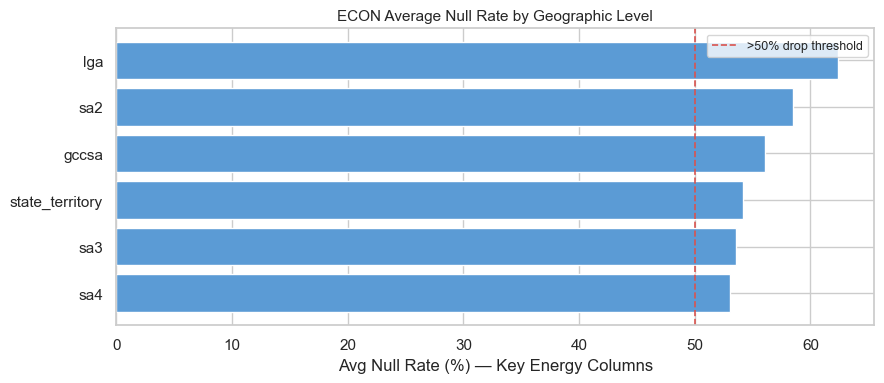

Saved: econ_null_rate_by_level.png


In [21]:
# --- Figure: ECON null rate by geographic level (justifies >50% drop & SA2-only focus) ---
_df_econ = datasets.get("ECON", econ_df).copy()

# Attach asgs_level from geo_info if missing
if "asgs_level" not in _df_econ.columns and "code" in _df_econ.columns:
    _df_econ = _df_econ.merge(
        geo_info[["code", "asgs_level"]].drop_duplicates("code"),
        on="code", how="left"
    )

_key_cols_econ = [c for c in [
    "total_number_of_businesses",
    "electricity,_gas,_water_and_waste_services_(no.)",
    "total_persons_employed_aged_15_years_and_over_(no.)",
    "value_of_total_building_($m)",
] if c in _df_econ.columns]

if "asgs_level" in _df_econ.columns and _key_cols_econ:
    _null_by_level = (
        _df_econ.groupby("asgs_level")[_key_cols_econ]
        .apply(lambda g: g.isna().mean() * 100)
        .mean(axis=1)
        .reset_index()
    )
    _null_by_level.columns = ["asgs_level", "avg_null_pct"]
    _null_by_level = _null_by_level.sort_values("avg_null_pct", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(_null_by_level["asgs_level"], _null_by_level["avg_null_pct"],
            color="#5b9bd5", edgecolor="white")
    ax.axvline(50, color="#d9534f", linestyle="--", linewidth=1.2, label=">50% drop threshold")
    ax.set_xlabel("Avg Null Rate (%) — Key Energy Columns")
    ax.set_title("ECON Average Null Rate by Geographic Level", fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig_dir = Path("figures"); fig_dir.mkdir(exist_ok=True)
    plt.savefig(fig_dir / "econ_null_rate_by_level.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: econ_null_rate_by_level.png")
else:
    print("WARNING: asgs_level or key columns not available — skipping plot")


## 3. Data augmentation (geocoding)

### 3-0 Supporting Functions (def)

In [22]:
facility_key_words = {
    'station', 'power', 'plant', 'facility', 'generator', 'generation', 'energy', # Primary infrastructure
    'wind', 'farm', 'solar', 'hydro', 'hydroelectric', 'renewable', 'array', # Renewable specific
    'thermal', 'gas', 'coal', 'turbine', 'engine', 'cogeneration','colliery', # Fossil/Process specific
    'battery', 'storage', 'bess', 'substation', 'terminal','pipelines' # Storage & Grid
}

def return_validation(cer_name, google_result, type='Facility', postcode=None, threshold=80):

    cer_name = str(cer_name).lower().strip()
    g_name = google_result.get('name', '').lower().strip()
    g_types  = google_result.get('types', [])
    components = google_result.get('address_components', [])

    # fix 1: don't overwrite g_postcode on every iteration
    g_postcode = None
    for component in components:
        if 'postal_code' in component.get('types', []):
            g_postcode = component.get('long_name', '')
            break

    if type == 'Facility':
        valid_categories = {
            'utility', 'industrial', 'establishment', 'storage',
            'farm', 'ranch', 'point_of_interest'
        }
    elif type == 'Power Station':
        valid_categories = {
            'industrial', 'establishment', 'hospital', 'university',
            'shopping_mall', 'utility', 'health', 'storage', 'point_of_interest'
        }

    category_match = any(t in valid_categories for t in g_types)
    contain_key_word = any(keyword in g_name for keyword in facility_key_words)
    name_score     = fuzz.partial_ratio(cer_name, g_name)

    if postcode is not None and g_postcode is not None:
        postcode_match = abs(int(g_postcode) - int(postcode)) <= 50
    else:
        postcode_match = None   # unknown, don't penalise

    # fix 2: don't require postcode_match when postcode is unknown
    is_verified = (name_score >= threshold and category_match) \
        or name_score >= 90 \
        or (name_score >= threshold*0.5 and category_match and contain_key_word)
    if postcode_match is not None:
        is_verified = is_verified and postcode_match
    if not is_verified:
        print(f'Failed to pass validation: {cer_name} -> {g_name}')

    return is_verified


In [23]:
def get_postcode_center(postcode):
    url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {"address": f"{postcode}, Australia", "key": GOOGLE_API}

    try:
        res = requests.get(url, params=params).json()
        if res['status'] == 'OK':
            loc = res['results'][0]['geometry']['location']
            return loc['lat'], loc['lng'], postcode, 'GG'
    except Exception:
        pass
    return None, None, postcode, 'GG'


### 3-1 Get Location for Facility (def)

In [24]:
def address_details_openmap(facility_name, state_label, postcode = None, wait=1):
    if postcode is not None:
        parameters = {'q': facility_name + ', ' + postcode + ', ' + state_label + ', Australia', 'format': 'json', 'addressdetails': 1}
    else:
        parameters = {'q': facility_name + ', ' + state_label + ', Australia', 'format': 'json', 'addressdetails': 1}
    base_url = 'https://nominatim.openstreetmap.org/search'
    headers = {'User-Agent': 'COMP5339_Assi1'}
    t.sleep(wait)  # second wait to avoid overloading
    try:
        response = requests.get(base_url, params = parameters, headers = headers)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        output = response.json()
    except requests.exceptions.RequestException as e:
        print(f"OpenStreetMap request failed: {e}")
        return None, None, None, None, None
    except json.JSONDecodeError:
        print(f"OpenStreetMap returned non-JSON response for {facility_name}, {state_label}, {postcode}")
        return None, None, None, None, None

    if not output:
        return None, None, None, None, None
    first_output = output[0]
    lat = first_output['lat']
    lng = first_output['lon']
    name_on_map = first_output['display_name']
    postcode = first_output.get("address", {}).get("postcode")
    source = 'OS'
    if postcode is not None:
        if not re.match(r"^\d{4}$", postcode):
            postcode = None
    return lat, lng, postcode, source, name_on_map

def address_details_google(facility_name, state_label, postcode = None, wait=0.3):
    if postcode is not None:
        query = f"{facility_name} {postcode}, {state_label}, Australia"
        threshold=60
    else:
        query = f"{facility_name}, {state_label}, Australia"
        threshold=80
    base_url = "https://maps.googleapis.com/maps/api/geocode/json" #abort because it didn't return the name
    base_url = "https://maps.googleapis.com/maps/api/place/textsearch/json"
    params = {
        "query": query,
        "key": GOOGLE_API
    }

    t.sleep(wait)  # polite delay
    try:
        r = requests.get(base_url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"Google API request failed: {e}")
        return None, None, None, None, None

    if data.get("status") != "OK" or not data.get("results"):
        print(f'Failed to connect API: {data.get("status")} on {facility_name} {state_label}')
        return None, None, None, None, None  # lat, lng, postcode, source, name_on_map

    google_result = data["results"][0]
    if not return_validation(facility_name, google_result, postcode=postcode, threshold=threshold):
        return None, None, None, None, None

    loc = google_result["geometry"]["location"]
    lat = loc["lat"]
    lng = loc["lng"]
    name_on_map = google_result.get('name', '')
    source = 'GG'

    for comp in google_result.get("address_components", []):
        if "postal_code" in comp.get("types", []):
            postcode = comp.get("long_name")
            if postcode is not None:
                if not re.match(r"^\d{4}$", postcode):
                    postcode = None
            break

    return lat, lng, postcode, source, name_on_map

def get_address_details(facility_name, state_label, postcode=None, wait= 1):
    # Try OpenStreetMap first (optional LGCS postcode tightens the query)
    lat, lng, pc, source, name_on_map = address_details_openmap(facility_name, state_label, postcode, wait)
    if lat is None or lng is None:
        return address_details_google(facility_name, state_label, postcode, wait*0.2)
    return lat, lng, pc, source, name_on_map


### 3-2 Makeup Partial Return (def)

In [25]:
def get_zipcode_from_coords_openmap(lat, lng):
    base_url = "https://nominatim.openstreetmap.org/reverse"
    params = {
        "lat": lat,
        "lon": lng,
        "format": "json",
        "addressdetails": 1,
    }
    headers = {
        "User-Agent": "COMP5339_Assi1",
    }
    try:
        response = requests.get(base_url, params=params, headers=headers, timeout=1)
        response.raise_for_status()
        data = response.json()
        addr = data.get("address") or {}
        # Nominatim often uses "postcode"; some regions use different keys
        raw_postcode = str(addr.get("postcode", "")).strip()
        if raw_postcode is not None and re.match(r"^\d{4}$", raw_postcode):
            return raw_postcode, 'OS'
        else:
            return None, 'OS'
    except Exception as e:
        print(f"Error in OSM reverse geocoding: {e}")
        return None, 'OS'

def get_zipcode_from_coords_google(lat, lng):
    base_url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {
        "latlng": f"{lat},{lng}",
        "key": GOOGLE_API
    }
    try:
        response = requests.get(base_url, params=params)
        data = response.json()
        if data['status'] == 'OK':
            for result in data['results']:
                for component in result['address_components']:
                    if 'postal_code' in component['types']:
                        if component['long_name'] is not None and re.match(r"^\d{4}$", component['long_name']):
                            return component['long_name'], 'GG'
                        else:
                            return None, 'GG'
        return None, 'GG'
    except Exception as e:
        print(f"Error in reverse geocoding: {e}")
        return None, 'GG'


### 3-4 Implement

#### 3-4-1 Geocoding for Facilities

In [26]:
#identify the facilities that need to be geocoded
to_be_crawled = nger_df.merge(fac_geo,on=['facility_name', 'state'], how='left')
to_be_crawled = to_be_crawled[to_be_crawled[['postcode', 'latitude', 'longitude']].isnull().any(axis=1)]
to_be_crawled = to_be_crawled[['facility_name', 'state']].drop_duplicates()
print(f"Found {len(fac_geo)} in cache. Need to crawl {len(to_be_crawled)} new facilities.")

if not to_be_crawled.empty:
    for col in ['postcode', 'latitude', 'longitude', 'source', 'name_on_map']:
        to_be_crawled[col] = None

    for i, (idx, row) in enumerate(to_be_crawled.iterrows()):
        facility_name = str(row['facility_name'])
        state_label = str(row['state'])

        lat, lng, postcode, source, name_on_map = get_address_details(facility_name, state_label, wait = 1)

        to_be_crawled.at[idx, 'latitude'] = lat
        to_be_crawled.at[idx, 'longitude'] = lng
        to_be_crawled.at[idx, 'name_on_map'] = name_on_map
        if postcode is None and lat is not None and lng is not None:
            postcode, source = get_zipcode_from_coords_openmap(lat, lng)
            if postcode is None:
                postcode, source = get_zipcode_from_coords_google(lat, lng)
        to_be_crawled.at[idx, 'postcode'] = postcode
        to_be_crawled.at[idx, 'source'] = source
        if i % 10 == 0:
            print(f" Crawled {i}/{len(to_be_crawled)}: {facility_name}")

    fac_geo_crawled = to_be_crawled.dropna(subset=['latitude', 'longitude'])
    fac_pre_crawled = fac_geo.dropna(subset=['latitude', 'longitude'])
    fac_with_geo = pd.concat([fac_pre_crawled, fac_geo_crawled], ignore_index=True)
    fac_with_geo = fac_with_geo.sort_values(by=['latitude', 'source'], ascending=[True, True], na_position='last')
    fac_with_geo = fac_with_geo.drop_duplicates(subset=['facility_name', 'state'], keep='first')

else:
    print(f"Already {len(fac_geo)} records with geo in dim_facility table. No need to crawl.")

Found 860 in cache. Need to crawl 134 new facilities.
Failed to pass validation: glenbawn hydro -> lake glenbawn
 Crawled 0/134: Glenbawn Hydro
Failed to pass validation: gess projectco pty ltd -> gess australia
Failed to connect API: ZERO_RESULTS on The RESS 1 Trust NSW
Failed to pass validation: the ress 2 trust -> national trust centre
Failed to pass validation: glennies creek wcmg power station -> integra underground coal mine
Failed to pass validation: lucas heights 1 lfg power station -> ansto - australia's nuclear science and technology organisation
Failed to pass validation: lucas heights 2 lfg power station -> cleanaway lucas heights resource recovery park
Failed to connect API: ZERO_RESULTS on VPP4S WA
Failed to pass validation: ravensthorpe power station -> ravensthorpe nickel mine
Failed to pass validation: ardyaloon facility -> ardyaloon aboriginal community
 Crawled 10/134: Ardyaloon Facility
Failed to pass validation: beagle bay facility -> beagle bay 'mother of pearl' c

#### 3-4-2 Geocoding for Power Station

In [27]:
#only run when the geo info of power station is not in the database
lgcs_be_crawled = lgcs_df.merge(pws_geo,on=['accreditation_code', 'state','postcode'], how='left')
lgcs_be_crawled = lgcs_be_crawled[lgcs_be_crawled[['latitude', 'longitude']].isnull().any(axis=1)]
lgcs_be_crawled = lgcs_be_crawled[['accreditation_code', 'state', 'postcode']].drop_duplicates()
print(f"Found {len(pws_geo)} in cache. Need to crawl {len(lgcs_be_crawled)} new large power stations.")

if not lgcs_be_crawled.empty:
    pws_geo = lgcs_df[['accreditation_code', 'power_station_name', 'state', 'postcode']].copy()
    pws_geo.rename(columns={'power_station_name': 'ori_station_name'}, inplace=True)
    pws_geo['new_station_name'] = (pws_geo['ori_station_name'].str.split(' - ', n=1).str[0].str.strip())
    pws_geo['latitude'] = None
    pws_geo['longitude'] = None
    pws_geo['source'] = None
    pws_geo['name_on_map'] = None

    for i, (idx, row) in enumerate(pws_geo.iterrows()):
        station_name = row['new_station_name']
        state_label = str(row['state'])
        postcode = str(row['postcode'])

        lat, lng, _postcode, source, name_on_map = get_address_details(station_name, state_label, postcode)
        if lat is None or lng is None:
            lat, lng, _postcode, source = get_postcode_center(postcode)
            name_on_map = '__use postcode centre__'
            print(f' - use centre of postcode {postcode}')

        pws_geo.at[idx, 'latitude'] = lat
        pws_geo.at[idx, 'longitude'] = lng
        pws_geo.at[idx, 'source'] = source
        pws_geo.at[idx, 'name_on_map'] = name_on_map

    pws_geo  = pws_geo.dropna(subset=['latitude', 'longitude'])
    if len(pws_geo) == 36:
        print("Craweled 36 power stations ")
else:
    print(f"Already {len(lgcs_be_crawled)} records in dim_lgcs table. No need to crawl.")


Found 57 in cache. Need to crawl 0 new large power stations.
Already 0 records in dim_lgcs table. No need to crawl.


### 3-5 Preparation for GeoShape

In [28]:
ALBERS = "EPSG:7845"
WGS84  = "EPSG:4326"

def enrich_geo_layer(slug: str, raw_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Reproject to WGS84, compute km2 / ha / representative centroid."""
    wgs = raw_gdf.to_crs(WGS84)
    alb = raw_gdf.to_crs(ALBERS)
    km2 = alb.geometry.area / 1e6
    rp  = wgs.representative_point()
    return gpd.GeoDataFrame(
        {
            "layer":       slug,
            "code":        raw_gdf["code"].values,
            "geo_name":    raw_gdf["geo_name"].values,
            "km2":         km2.astype(float).values,
            "ha":          (km2 * 100).astype(float).values,
            "central_lat": rp.y.astype(float).values,
            "central_lng": rp.x.astype(float).values,
        },
        geometry=wgs.geometry.values,
        crs=WGS84,
    ).dropna(subset=["km2", "central_lat", "central_lng"])


def build_postcode_lists(
    all_gdfs: dict[str, gpd.GeoDataFrame],
    poa_gdf: gpd.GeoDataFrame,
    min_overlap_pct: float = 0.1,
) -> dict[tuple, list[str]]:
    """
    Build {(layer, code): [postcodes]} map.
    SA2: full spatial join with POA (most precise, but slow).
    SA3 / SA4 / STE: roll up from children — spatial join only for regions
                     whose children have no postcodes.
    GCCSA / LGA: spatial join (not in SA2→SA3→SA4→STE hierarchy).
    """
    result: dict[tuple, list[str]] = {}

    poa_alb = (
        poa_gdf[["code", "geometry"]].copy()
        .to_crs(ALBERS)
        .rename(columns={"code": "postcode"})
    )
    poa_alb["poa_area"] = poa_alb.geometry.area

    def _sjoin_layer(slug: str, gdf: gpd.GeoDataFrame):
        """Spatial join one layer against POA, store results in result."""
        regions = gdf[["code", "geometry"]].copy().to_crs(ALBERS)
        joined  = gpd.sjoin(regions, poa_alb, how="left", predicate="intersects")
        def _ov(row):
            if pd.isna(row.get("postcode")):
                return 0.0
            try:
                return (
                    regions.loc[row.name, "geometry"]
                    .intersection(poa_alb.loc[row["index_right"], "geometry"])
                    .area / row["poa_area"]
                )
            except Exception:
                return 0.0
        joined["overlap_frac"] = joined.apply(_ov, axis=1)
        grouped = (
            joined[joined["overlap_frac"] >= min_overlap_pct]
            .dropna(subset=["postcode"])
            .groupby("code")["postcode"]
            .apply(lambda x: sorted(set(x)))
        )
        for code, pcs in grouped.items():
            result[(slug, str(code))] = list(pcs)

    def _rollup(parent_slug: str, child_slug: str, prefix_len: int):
        """Roll up postcodes from child layer to parent via code prefix.
        Falls back to spatial join for parents with no children in result."""
        parent_gdf = all_gdfs.get(parent_slug)
        if parent_gdf is None:
            return
        rows = [
            {"child_code": k[1], "postcode": pc}
            for k, pcs in result.items() if k[0] == child_slug
            for pc in pcs
        ]
        covered: set[str] = set()
        if rows:
            _df = pd.DataFrame(rows)
            _df["parent_code"] = _df["child_code"].str[:prefix_len]
            for pcode, grp in _df.groupby("parent_code"):
                result[(parent_slug, str(pcode))] = sorted(set(grp["postcode"]))
                covered.add(str(pcode))
        uncovered = set(parent_gdf["code"].astype(str)) - covered
        if uncovered:
            print(f"  {parent_slug}: {len(uncovered)} regions with no child postcodes — spatial join fallback")
            _sjoin_layer(parent_slug, parent_gdf[parent_gdf["code"].astype(str).isin(uncovered)])
        else:
            print(f"  {parent_slug}: all regions covered by rollup")

    # SA2 first — full spatial join
    if "sa2_2021" in all_gdfs:
        print("  sa2_2021: spatial join with POA...")
        _sjoin_layer("sa2_2021", all_gdfs["sa2_2021"])
        print(f"    {sum(1 for k in result if k[0]=='sa2_2021')} SA2 regions with postcodes")

    # Roll up: SA3 ← SA2, SA4 ← SA3, STE ← SA4
    _rollup("sa3_2021", "sa2_2021", 5)
    _rollup("sa4_2021", "sa3_2021", 3)
    _rollup("ste_2021", "sa4_2021", 1)

    # GCCSA and LGA are not in the SA hierarchy — spatial join directly
    for slug in ("gccsa_2021", "lga_2025"):
        if slug in all_gdfs:
            print(f"  {slug}: spatial join...")
            _sjoin_layer(slug, all_gdfs[slug])

    return result


### 3-6 Build the GeoShape

In [29]:
# --- 3-6. Build gov_geo_info ---

if geo_regions.empty:
    # Step 1: Enrich each raw layer (km2, ha, centroid, reproject to WGS84)
    enriched_gdfs: dict[str, gpd.GeoDataFrame] = {}
    for _slug, _raw in raw_geo_layers.items():
        enriched_gdfs[_slug] = enrich_geo_layer(_slug, _raw)
        print(f"  {_slug}: {len(enriched_gdfs[_slug])} regions enriched")

    # Step 2: Assign parent_code
    def _parent_code(slug: str, code: str) -> str:
        c = str(code).strip()
        if slug == "sa2_2021"  and len(c) == 9 and c.isdigit(): return c[:5]
        if slug == "sa3_2021"  and len(c) == 5 and c.isdigit(): return c[:3]
        if slug == "sa4_2021"  and len(c) == 3 and c.isdigit(): return c[:1]
        if slug in ("gccsa_2021", "lga_2025"):                  return c[:1]
        return "AUS"  # ste_2021

    for _slug, _gdf in enriched_gdfs.items():
        enriched_gdfs[_slug] = _gdf.assign(
            parent_code=_gdf["code"].apply(lambda c: _parent_code(_slug, c))
        )
    print("parent_code assigned")

    # Step 3: Postcode lists
    # SA2 runs full spatial join; SA3/SA4/STE roll up from children.
    if raw_poa_gdf is not None:
        _poa_enriched = enrich_geo_layer("poa_2021", raw_poa_gdf)
        print("Building postcode lists...")
        postcode_map = build_postcode_lists(enriched_gdfs, _poa_enriched)
    else:
        print("Warning: no POA layer found — postcode_list will be empty.")
        postcode_map = {}

    # Step 4: Combine layers, attach postcode_list
    all_frames = []
    for _slug, _gdf in enriched_gdfs.items():
        _gdf = _gdf.copy()
        _gdf["postcode_list"] = _gdf["code"].apply(lambda c: postcode_map.get((_slug, str(c)), []))
        all_frames.append(_gdf)
        print(f"  {_slug}: avg {_gdf['postcode_list'].apply(len).mean():.1f} postcodes/region")

    gov_geo_regions = pd.concat(all_frames, ignore_index=True)

    # PostgreSQL TEXT[] literal format
    gov_geo_regions["postcode_list"] = gov_geo_regions["postcode_list"].apply(
        lambda v: "{" + ",".join(v or []) + "}"
    )

    # change the order of the columns
    gov_geo_regions = gov_geo_regions[['layer', 'code', 'geo_name', 'km2', 'ha', 'central_lat', 'central_lng', 'postcode_list', 'parent_code', 'geometry']]

    # Keep geometry column — serialised to GeoJSON in 4-3-3 just before DB insert
    print(f"\ngov_geo_info ready: {len(gov_geo_regions)} rows")
else:
    enriched_gdfs: dict[str, gpd.GeoDataFrame] = {}
    for layer in geo_regions['layer'].unique():
        enriched_gdfs[layer] = geo_regions[geo_regions['layer'] == layer].copy()
        print(f"  {layer}: {len(enriched_gdfs[layer])} regions enriched")
    print(f"\geo_region already here: {len(geo_regions)} rows")


  gccsa_2021: 16 regions enriched
  lga_2025: 548 regions enriched
  sa2_2021: 2454 regions enriched
  sa3_2021: 340 regions enriched
  sa4_2021: 89 regions enriched
  ste_2021: 9 regions enriched
\geo_region already here: 3456 rows


### 3-7 Geocoding Visualisation

Map of all geocoded NGER facilities and LGCS power stations across Australia.

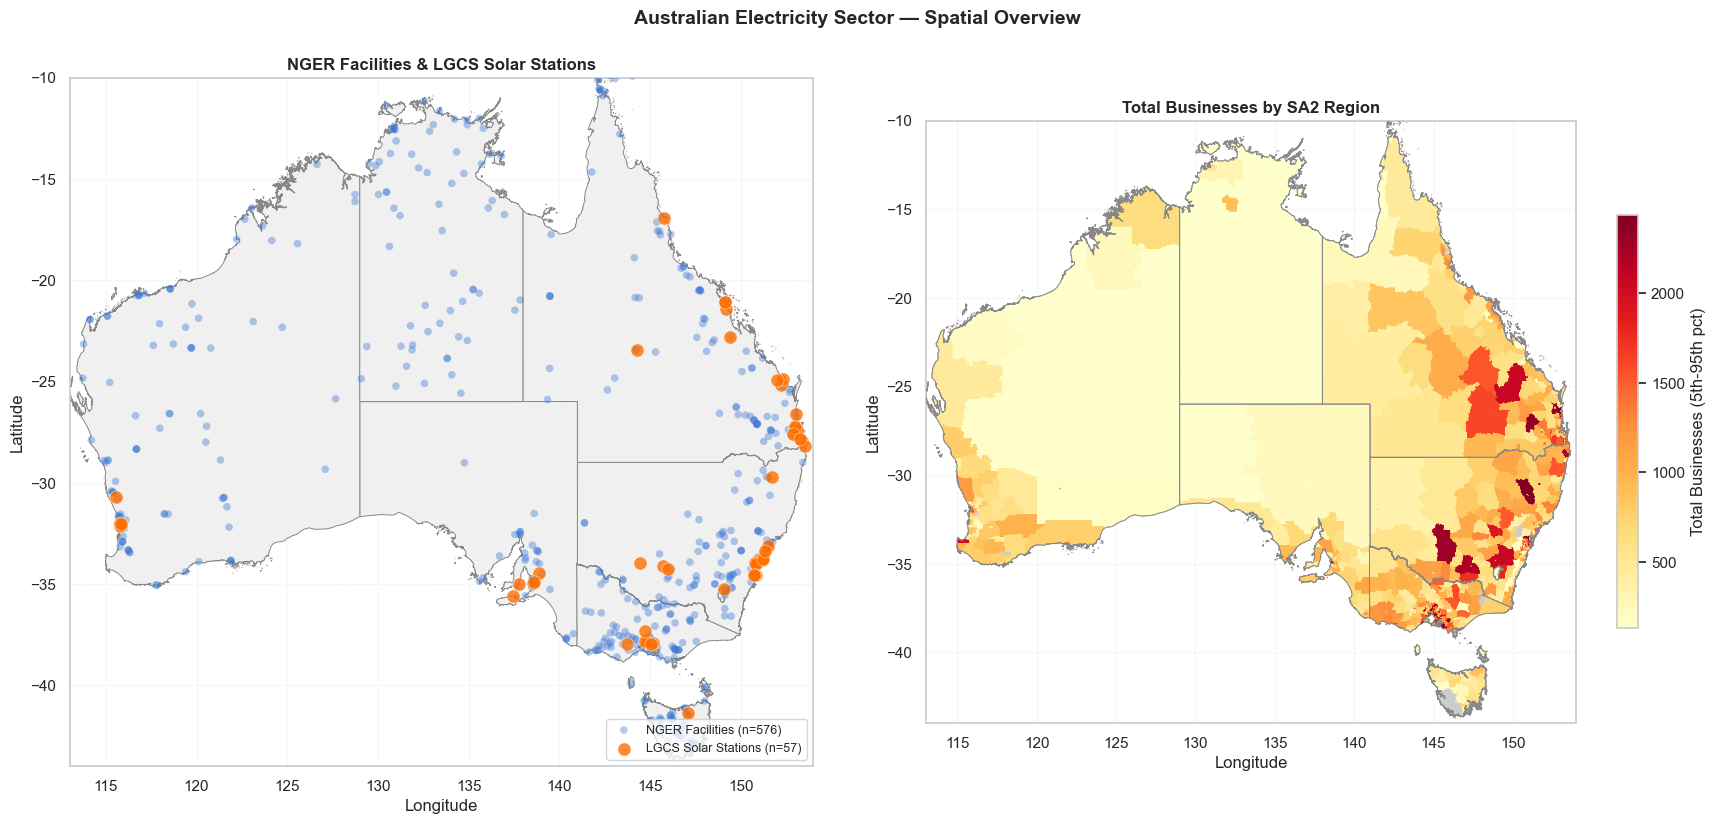

Saved: facility_lgcs_map.png


In [30]:
# --- Figure: Two-panel Australian map ---
# Left:  NGER facilities + LGCS power stations geocoded locations
# Right: Total businesses by SA2 region (choropleth, 5th-95th percentile colour scale)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# State boundaries — from enriched_gdfs built in 3-6
_states = enriched_gdfs.get("ste_2021")
if _states is not None:
    _states.plot(ax=ax1, color="#f0f0f0", edgecolor="#888888", linewidth=0.7, zorder=1)
    _states.plot(ax=ax2, color="#f0f0f0", edgecolor="#888888", linewidth=0.7, zorder=1)

# ── Map 1: Facility and LGCS locations ───────────────────────────────────────
# NGER facilities — use dim_faci loaded from DB at startup (has geocoded lat/lng)
_fac = pd.DataFrame()
for _src in ["dim_faci", "dim_facility", "fac_geo"]:
    if _src in dir() and not eval(_src).empty:
        _candidate = eval(_src)
        if "latitude" in _candidate.columns and "longitude" in _candidate.columns:
            _fac = _candidate.dropna(subset=["latitude", "longitude"]).drop_duplicates(subset=["latitude", "longitude"])
            break

if len(_fac) > 0:
    ax1.scatter(_fac["longitude"], _fac["latitude"],
                s=30, alpha=0.40, c="#3c78d8", edgecolors="none",
                label=f"NGER Facilities (n={len(_fac)})", zorder=3)

# LGCS power stations (larger circles, more opaque)
_lgcs_pts = pd.DataFrame()
if "pws_geo" in dir() and "latitude" in pws_geo.columns:
    _lgcs_pts = pws_geo.dropna(subset=["latitude", "longitude"])
elif "lgcs_df" in dir() and "latitude" in lgcs_df.columns:
    _lgcs_pts = lgcs_df.dropna(subset=["latitude", "longitude"])

if len(_lgcs_pts) > 0:
    ax1.scatter(_lgcs_pts["longitude"], _lgcs_pts["latitude"],
                s=90, alpha=0.8, c="#FF6F00", marker="o", edgecolors="white", linewidths=0.4,
                label=f"LGCS Solar Stations (n={len(_lgcs_pts)})", zorder=4)

ax1.set_xlim(113, 154); ax1.set_ylim(-44, -10)
ax1.set_title("NGER Facilities & LGCS Solar Stations", fontsize=12, fontweight="bold")
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.2, linestyle="--")

# ── Map 2: Total businesses by SA2 choropleth ────────────────────────────────
_sa2 = enriched_gdfs.get("sa2_2021")
if _sa2 is not None:
    _econ_sa2 = datasets.get("ECON", econ_df).copy()
    _econ_sa2["code"] = _econ_sa2["code"].astype(str).str.strip()

    _tb_col = "total_number_of_businesses"
    if _tb_col in _econ_sa2.columns:
        _econ_sa2 = _econ_sa2[
            _econ_sa2["code"].str.match(r'^\d{9}$')
        ][["code", _tb_col]].copy()
        _econ_sa2[_tb_col] = pd.to_numeric(_econ_sa2[_tb_col], errors="coerce")
        _econ_sa2 = _econ_sa2.dropna(subset=[_tb_col])

        _vmin = np.nanpercentile(_econ_sa2[_tb_col], 5)
        _vmax = np.nanpercentile(_econ_sa2[_tb_col], 95)

        _sa2_plot = _sa2.copy()
        _sa2_plot["code"] = _sa2_plot["code"].astype(str).str.strip()
        _sa2_plot = _sa2_plot.merge(_econ_sa2, on="code", how="left")

        _sa2_plot.plot(
            column=_tb_col, ax=ax2,
            cmap="YlOrRd",
            vmin=_vmin, vmax=_vmax,
            legend=True,
            legend_kwds={"label": "Total Businesses (5th-95th pct)", "shrink": 0.6},
            missing_kwds={"color": "#cccccc", "label": "No data"},
            edgecolor="none", linewidth=0, zorder=2
        )
        if _states is not None:
            _states.plot(ax=ax2, color="none", edgecolor="#888888", linewidth=0.7, zorder=3)
        ax2.set_title("Total Businesses by SA2 Region", fontsize=12, fontweight="bold")
    else:
        ax2.text(0.5, 0.5, f"Column '{_tb_col}' not found in ECON data",
                 ha="center", va="center", transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, "sa2_2021 layer not found in enriched_gdfs",
             ha="center", va="center", transform=ax2.transAxes)

ax2.set_xlim(113, 154); ax2.set_ylim(-44, -10)
ax2.set_xlabel("Longitude"); ax2.set_ylabel("Latitude")
ax2.grid(True, alpha=0.2, linestyle="--")

plt.suptitle("Australian Electricity Sector — Spatial Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig_dir = Path("figures"); fig_dir.mkdir(exist_ok=True)
plt.savefig(fig_dir / "facility_lgcs_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: facility_lgcs_map.png")


## 4 Transformation and database schema

### 4-1 Schema setting (def)

In [31]:
def enable_postgis():
    """Enable PostGIS spatial extension on Neon PostgreSQL."""
    cur.execute("CREATE EXTENSION IF NOT EXISTS postgis;")
    conn.commit()
    print("PostGIS extension enabled.")


### 4-2 Save Geocoding into DB (def)

In [32]:
def save_df_into_db(df, table_create_query, insert_query, execute_list=[], template='', drop_table=''):
    conn.rollback()
    if drop_table != '':
        cur.execute("DROP TABLE IF EXISTS " + drop_table + " CASCADE;")
    cur.execute(table_create_query)
    for i in execute_list:
        cur.execute(i)
    conn.commit()

    data_tuples = [
        tuple(None if (not isinstance(x, (list, np.ndarray)) and pd.isna(x)) else x for x in row)
        for row in df.values
    ]

    template_list = "(%s, %s, %s, %s, %s, %s, %s, %s, %s, ST_GeomFromGeoJSON(%s))"                  if template == 'geo_region' else \
                    "(%s, %s, %s, %s, %s, %s, %s, %s, %s::geometry)"                                if template == 'dim_fact'   else \
                    "(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s::geometry)"    if template == 'dim_lgcs'   else \
                    "(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s::jsonb)"                               if template == 'fact_econ'  else \
                    "(%s)"                                                                          if template == 'dim_year'  else None

    psycopg2.extras.execute_values(cur, insert_query, data_tuples, template=template_list)
    conn.commit()

    print(f"Successfully synced {len(df)} records of {template} to Neon.")


In [33]:
def verify_table(table_name, coords_col, geom_col):

    cur.execute(f"SELECT COUNT(*) FROM {table_name};")
    total = cur.fetchone()[0]

    cur.execute(f"SELECT COUNT(*) FROM {table_name} WHERE {coords_col} IS NOT NULL;")
    with_coords = cur.fetchone()[0]

    cur.execute(f"SELECT COUNT(*) FROM {table_name} WHERE {geom_col} IS NOT NULL;")
    with_geom = cur.fetchone()[0]

    print(f"\n{table_name} results:")
    print(f"  Total facilities : {total:,}")
    print(f"  With coordinates : {with_coords:,}")
    print(f"  With PostGIS geom: {with_geom:,}")
    print(f"  No coordinates   : {total - with_coords:,}")



### 4-3 Insert / Update the table in DB

In [34]:
conn = try_connect("neondb")
cur  = conn.cursor()

enable_postgis()

# Schema migrations — safe to run on existing DB
for _sql in [
    "ALTER TABLE IF EXISTS geo_regions ADD COLUMN IF NOT EXISTS parent_code TEXT;",
    "ALTER TABLE IF EXISTS dim_facility ADD COLUMN IF NOT EXISTS sa2_code TEXT;",
    "ALTER TABLE IF EXISTS dim_lgcs     ADD COLUMN IF NOT EXISTS sa2_code TEXT;",
    "ALTER TABLE IF EXISTS fact_nger    ADD COLUMN IF NOT EXISTS year_id INTEGER REFERENCES dim_year(year_id);",
    "ALTER TABLE IF EXISTS fact_econ    ADD COLUMN IF NOT EXISTS year_id INTEGER REFERENCES dim_year(year_id);",
]:
    try:
        cur.execute(_sql); conn.commit()
    except Exception as _e:
        conn.rollback(); print(f"Migration skip: {_e}")


PostGIS extension enabled.


#### 4-3-1 dim_Fuel table

In [35]:
fuel_col = 'primary_fuel' if 'primary_fuel' in nger_df.columns else 'Primary fuel'
nger_fuels = nger_df[fuel_col].dropna().unique().tolist() if fuel_col in nger_df.columns else []
lgcs_fuels = lgcs_df[next((c for c in lgcs_df.columns if 'fuel' in c.lower()), None)].dropna().unique().tolist() \
    if any('fuel' in c.lower() for c in lgcs_df.columns) else []

all_fuels  = sorted(set(nger_fuels) | set(lgcs_fuels))
fuel_df    = pd.DataFrame([(f, f in RENEWABLE_FUELS) for f in all_fuels], columns=['fuel_name', 'is_renewable'])

create_fuel_table = """
    CREATE TABLE IF NOT EXISTS dim_fuel (
        fuel_id      SERIAL PRIMARY KEY,
        fuel_name    TEXT    NOT NULL UNIQUE,
        is_renewable BOOLEAN NOT NULL DEFAULT FALSE
    );
"""
insert_fuel = """
    INSERT INTO dim_fuel (fuel_name, is_renewable)
    VALUES %s
    ON CONFLICT (fuel_name) DO NOTHING;
"""

save_df_into_db(fuel_df, create_fuel_table, insert_fuel, template='dim_fuel')


Successfully synced 22 records of dim_fuel to Neon.


#### 4-3-1b dim_year table

In [36]:
# Build dim_year from all years present across NGER and ECON
_nger_years = nger_df["source_year"].dropna().astype(int).unique().tolist()
_econ_years = datasets.get("ECON", econ_df)["year"].dropna().astype(int).unique().tolist() \
             if "year" in datasets.get("ECON", econ_df).columns else []
dim_year_df = pd.DataFrame({"year": sorted(set(_nger_years + _econ_years))})
dim_year_df  = dim_year_df.astype({"year": "object"})

create_year_table = """
    CREATE TABLE IF NOT EXISTS dim_year (
        year_id  SERIAL PRIMARY KEY,
        year     SMALLINT NOT NULL,
        UNIQUE (year)
    );
"""
insert_year = """
    INSERT INTO dim_year (year) VALUES %s
    ON CONFLICT (year) DO NOTHING;
"""
save_df_into_db(dim_year_df, create_year_table, insert_year, template='dim_year')


Successfully synced 12 records of dim_year to Neon.


#### 4-3-2 dim_facility table

In [37]:
# add geom to dim_facility
dim_fact = nger_df[['facility_name', 'state']].drop_duplicates().merge(fac_with_geo, on=['facility_name', 'state'], how='left')
dim_fact["geom"] = dim_fact.apply(
    lambda r: f"SRID=4326;POINT({r['longitude']} {r['latitude']})"
    if pd.notna(r["latitude"]) and pd.notna(r["longitude"])
    else None,
    axis=1,
)
# SA2 spatial join — only fill rows where sa2_code is still null
_sa2_raw = enriched_gdfs.get("sa2_2021")
if _sa2_raw is not None:
    _sa2 = _sa2_raw[["code","geometry"]].rename(columns={"code":"sa2_code"})
    _needs_sa2 = dim_fact[dim_fact["sa2_code"].isna()].dropna(subset=["latitude","longitude"])
    if len(_needs_sa2) > 0:
        _gdf = gpd.GeoDataFrame(_needs_sa2,
                                geometry=gpd.points_from_xy(_needs_sa2["longitude"], _needs_sa2["latitude"]),
                                crs="EPSG:4326")
        # point-in-polygon join maps each point to SA2 for regional linking.
        _joined = gpd.sjoin(_gdf, _sa2, how="left", predicate="within")
        _joined = _joined.drop_duplicates(subset=["facility_name","state"])[["facility_name","state","sa2_code_right"]]
        _joined = _joined.rename(columns={"sa2_code_right":"sa2_code_new"})

        # null-only backfill keeps reruns idempotent and avoids overwriting reviewed SA2 mappings.
        dim_fact = dim_fact.merge(_joined, on=["facility_name","state"], how="left")
        dim_fact["sa2_code"] = dim_fact["sa2_code"].fillna(dim_fact["sa2_code_new"])
        dim_fact.drop(columns=["sa2_code_new"], inplace=True)
        print(f"SA2 assigned: {dim_fact['sa2_code'].notna().sum()}/{len(dim_fact)} facilities")
    else:
        print("All sa2_code already mapped, skipping spatial join")
else:
    print("WARNING: sa2_2021 not in enriched_gdfs — sa2_code will be NULL")

dim_fact = dim_fact[["facility_name","state","postcode","latitude","longitude","source","name_on_map","sa2_code","geom"]]
dim_fact = dim_fact.drop_duplicates(subset=['facility_name', 'state'])

# SQL syntax
create_facility_table = """
    CREATE TABLE IF NOT EXISTS dim_facility (
        facility_id   SERIAL PRIMARY KEY,
        facility_name TEXT,
        name_on_map   TEXT,
        state         TEXT,
        postcode      TEXT CHECK (postcode ~ '^[0-9]{4}$' OR postcode IS NULL),
        latitude      FLOAT,
        longitude     FLOAT,
        source        CHAR(2),
        geom          GEOMETRY(POINT, 4326),
        sa2_code      TEXT,
        UNIQUE (facility_name, state)
    );
"""
facility_geo_update = """
    INSERT INTO dim_facility (facility_name, state, postcode, latitude, longitude, source, name_on_map, sa2_code, geom)
    VALUES %s
    ON CONFLICT (facility_name, state) DO UPDATE SET
        postcode  = EXCLUDED.postcode,
        latitude  = EXCLUDED.latitude,
        longitude = EXCLUDED.longitude,
        source    = EXCLUDED.source,
        name_on_map = EXCLUDED.name_on_map,
        sa2_code    = EXCLUDED.sa2_code,
        geom      = EXCLUDED.geom;
"""

facility_geo_executes = [
    "CREATE EXTENSION IF NOT EXISTS postgis;",
    "CREATE INDEX IF NOT EXISTS dim_facility_geom_idx ON dim_facility USING GIST (geom);"
]

save_df_into_db(dim_fact, create_facility_table, facility_geo_update, facility_geo_executes, 'dim_fact')
verify_table('dim_facility', 'latitude', 'geom')


SA2 assigned: 727/858 facilities
Successfully synced 858 records of dim_fact to Neon.

dim_facility results:
  Total facilities : 860
  With coordinates : 729
  With PostGIS geom: 729
  No coordinates   : 131


#### 4-3-3 dim_lgcs

In [38]:
# merge the lgcs and its geo info
dim_lgcs = lgcs_df.merge(pws_geo, on=['accreditation_code','state','postcode'], how='left')
# align column names to match INSERT statement
dim_lgcs = dim_lgcs.rename(columns={
    "accreditation_start_date": "accreditation_start",
    "installed_capacity_(mw)": "capacity_mw",
    "fuel_source(s)":         "fuel_type",
    "power_station_name":     "ori_station_name"
})
#create lgcs appear date 
dim_lgcs["data_acq_date"] = datetime.date.today().isoformat()
# create geom column
dim_lgcs["geom"] = dim_lgcs.apply(
    lambda r: f"SRID=4326;POINT({r['longitude']} {r['latitude']})"
    if pd.notna(r["latitude"]) and pd.notna(r["longitude"])
    else None,
    axis=1,
)

# SA2 spatial join for LGCS power stations — only fill null sa2_code rows
_sa2_raw = enriched_gdfs.get("sa2_2021")
if _sa2_raw is not None and "latitude" in dim_lgcs.columns:
    _sa2 = _sa2_raw[["code","geometry"]].rename(columns={"code":"sa2_code"})
    _needs_sa2 = dim_lgcs[dim_lgcs["sa2_code"].isna()].dropna(subset=["latitude","longitude"])
    if len(_needs_sa2) > 0:
        _gdf = gpd.GeoDataFrame(_needs_sa2,
                                geometry=gpd.points_from_xy(_needs_sa2["longitude"], _needs_sa2["latitude"]),
                                crs="EPSG:4326")
        _joined = gpd.sjoin(_gdf, _sa2, how="left", predicate="within")
        _joined = _joined.drop_duplicates(subset=["accreditation_code"])[["accreditation_code","sa2_code"]]
        dim_lgcs = dim_lgcs.merge(_joined.rename(columns={"sa2_code":"sa2_code_new"}),
                                  on="accreditation_code", how="left")
        dim_lgcs["sa2_code"] = dim_lgcs["sa2_code"].fillna(dim_lgcs["sa2_code_new"])
        dim_lgcs.drop(columns=["sa2_code_new"], inplace=True)
        print(f"SA2 assigned: {dim_lgcs['sa2_code'].notna().sum()}/{len(dim_lgcs)} LGCS stations")
    else:
        print("All sa2_code already mapped, skipping spatial join")
else:
    dim_lgcs["sa2_code"] = None

# reorder columns to match INSERT statement exactly
_LGCS_COLS = ['accreditation_code', 'ori_station_name', 'state', 'postcode',
              'capacity_mw', 'fuel_type', 'accreditation_start', 'approval_date',
              'new_station_name', 'latitude', 'longitude', 'source', 'name_on_map',
              'sa2_code', 'data_acq_date','geom']
dim_lgcs = dim_lgcs[_LGCS_COLS]


create_lgcs_table = """
    CREATE TABLE IF NOT EXISTS dim_lgcs (
        accreditation_code TEXT PRIMARY KEY,
        ori_station_name TEXT,
        new_station_name TEXT,
        fuel_type TEXT,
        capacity_mw TEXT,
        accreditation_start DATE,
        approval_date DATE,
        state TEXT,
        postcode TEXT CHECK (postcode ~ '^[0-9]{4}$' OR postcode IS NULL),
        latitude FLOAT,
        longitude FLOAT,
        name_on_map TEXT,
        source TEXT,
        sa2_code TEXT,
        data_acq_date DATE,
        geom GEOMETRY(POINT, 4326)
    );
"""

insert_lgcs = """
    INSERT INTO dim_lgcs (accreditation_code, ori_station_name, state, postcode, capacity_mw, fuel_type, accreditation_start, approval_date, new_station_name, latitude, longitude, source, name_on_map, sa2_code, data_acq_date, geom)
    VALUES %s
    ON CONFLICT (accreditation_code) DO NOTHING;

"""

save_df_into_db(dim_lgcs, create_lgcs_table, insert_lgcs, template='dim_lgcs', drop_table='dim_lgcs')

All sa2_code already mapped, skipping spatial join
Successfully synced 57 records of dim_lgcs to Neon.


#### 4-3-3 Gov Geo Info

In [39]:
create_geo_table = """
    CREATE TABLE IF NOT EXISTS geo_regions (
        id             SERIAL PRIMARY KEY,
        layer          TEXT        NOT NULL,
        code           TEXT        NOT NULL,
        geo_name       TEXT,
        km2            DOUBLE PRECISION,
        ha             DOUBLE PRECISION,
        central_lat    DOUBLE PRECISION,
        central_lng    DOUBLE PRECISION,
        postcode_list  TEXT[]      DEFAULT '{}',
        parent_code    TEXT,
        geom           GEOMETRY(GEOMETRY, 4326),
        UNIQUE (layer, code)
    );
"""
geo_executes = ["CREATE EXTENSION IF NOT EXISTS postgis;",
                "CREATE INDEX IF NOT EXISTS geo_regions_geom_idx ON geo_regions USING GIST (geom);",
                "CREATE INDEX IF NOT EXISTS geo_regions_postcode_idx ON geo_regions USING GIN (postcode_list);"]
insert_geo = """
    INSERT INTO geo_regions (layer, code, geo_name, km2, ha, central_lat, central_lng, postcode_list, parent_code, geom)
    VALUES %s
    ON CONFLICT (layer, code) DO UPDATE SET
        geo_name      = EXCLUDED.geo_name,
        km2           = EXCLUDED.km2,
        ha            = EXCLUDED.ha,
        central_lat   = EXCLUDED.central_lat,
        central_lng   = EXCLUDED.central_lng,
        postcode_list = EXCLUDED.postcode_list,
        parent_code   = EXCLUDED.parent_code,
        geom          = EXCLUDED.geom;
"""
if geo_regions.empty:
    # Serialise geometry as GeoJSON string for PostGIS ST_GeomFromGeoJSON()
    geo_to_db = gov_geo_regions.copy()
    geo_to_db['geometry'] = geo_to_db.geometry.simplify(0.001, preserve_topology=True)
    geo_to_db["geom"] = geo_to_db.geometry.apply(lambda g: json.dumps(g.__geo_interface__) if g is not None else None)
    geo_to_db.drop(columns=["geometry"], inplace=True)

    save_df_into_db(geo_to_db, create_geo_table, insert_geo, geo_executes, template='geo_region', drop_table='geo_regions')


#### 4-3-4 fact_nger

In [40]:
# ── Prepare fact_nger ─────────────────────────────────────────────────────────

# Build FK lookup tables from dim tables already saved in DB
cur.execute("SELECT facility_id, facility_name, state FROM dim_facility;")
fac_lookup = {
    ((r[1] or "").strip().lower(), (r[2] or "").strip().lower()): r[0]
    for r in cur.fetchall()
}
cur.execute("SELECT fuel_id, fuel_name FROM dim_fuel;")
fuel_lookup = {r[1].strip().lower(): r[0] for r in cur.fetchall()}
cur.execute("SELECT year_id, year FROM dim_year;")
year_lookup = {int(r[1]): r[0] for r in cur.fetchall()}

fact_nger_df = nger_df.copy()

# Map facility_id and fuel_id via FK lookups
# convert business keys to surrogate FK ids before fact insert for referential integrity.
fact_nger_df["facility_id"] = fact_nger_df.apply(
    lambda r: fac_lookup.get((
        str(r.get("facility_name") or "").strip().lower(),
        str(r.get("state")         or "").strip().lower()
    )), axis=1
).astype("Int64")
fact_nger_df["fuel_id"] = fact_nger_df["primary_fuel"].apply(
    lambda v: fuel_lookup.get(str(v or "").strip().lower())
).astype("Int64")
fact_nger_df["year_id"] = fact_nger_df["source_year"].apply(
    lambda v: year_lookup.get(int(v)) if pd.notna(v) else None
).astype("Int64")

# Normalise grid_connected → boolean
if "grid_connected" not in fact_nger_df.columns and "grid_connected2" in fact_nger_df.columns:
    fact_nger_df["grid_connected"] = fact_nger_df["grid_connected2"]

_GC_MAP = {"ON": True, "OFF": False, "TRUE": True, "FALSE": False,
           "Y": True, "N": False, "YES": True, "NO": False, "1": True, "0": False}
if "grid_connected" in fact_nger_df.columns:
    fact_nger_df["grid_connected"] = fact_nger_df["grid_connected"].map(
        lambda v: (pd.NA if pd.isna(v)
                   else bool(v) if isinstance(v, (bool, np.bool_))
                   else _GC_MAP.get(str(v).strip().upper(), pd.NA))
    ).astype("boolean")
elif "grid" in fact_nger_df.columns:
    _OFF_GRID = {"off-grid", "off grid", "offgrid", "isolated"}
    _ON_GRID  = {"nem", "swis", "nwis", "mt isa", "mt_isa", "grid"}
    fact_nger_df["grid_connected"] = fact_nger_df["grid"].map(
        lambda g: (pd.NA if pd.isna(g)
                   else False if str(g).strip().lower() in _OFF_GRID
                   else True  if str(g).strip().lower() in _ON_GRID
                   else pd.NA)
    ).astype("boolean")
else:
    fact_nger_df["grid_connected"] = pd.Series(pd.NA, index=fact_nger_df.index, dtype="boolean")

# Cast numeric columns to float
float_cols = [
    "electricity_production_gj", "electricity_production_mwh",
    "total_scope_1_emissions_t_co2_e", "total_scope_2_emissions_t_co2_e",
    "total_emissions_t_co2_e", "emission_intensity_t_co2_e_mwh"
]
fact_nger_df[float_cols] = fact_nger_df[float_cols].astype(float)

# Report unmatched rows (~18% expected — facilities without geocoded coords)
skipped = fact_nger_df[fact_nger_df["facility_id"].isna()]
if len(skipped):
    print(f"Skipped {len(skipped)} rows with no facility match:")
    print(skipped[["facility_name","state"]].drop_duplicates().head())

# Select final columns for insert
# rows with missing facility_id are excluded to avoid FK violations; they are logged above.
fact_nger_df = fact_nger_df.dropna(subset=["facility_id"])[[
    "facility_id", "fuel_id", "year_id", "reporting_entity", "type", "source_year",
    "electricity_production_gj", "electricity_production_mwh",
    "total_scope_1_emissions_t_co2_e", "total_scope_2_emissions_t_co2_e",
    "total_emissions_t_co2_e", "emission_intensity_t_co2_e_mwh",
    "grid_connected", "grid", "important_notes"
]]

# ── SQL ───────────────────────────────────────────────────────────────────────

create_fact_nger = """
    CREATE TABLE IF NOT EXISTS fact_nger (
        nger_id            SERIAL PRIMARY KEY,
        facility_id        INT   REFERENCES dim_facility(facility_id),
        fuel_id            INT   REFERENCES dim_fuel(fuel_id),
        reporting_entity   TEXT,
        type               TEXT,
        year_id            INT   REFERENCES dim_year(year_id),
        source_year        INT   NOT NULL,
        elec_prod_gj       FLOAT,
        elec_prod_mwh      FLOAT,
        scope1_emissions   FLOAT,
        scope2_emissions   FLOAT,
        total_emissions    FLOAT,
        emission_intensity FLOAT,
        grid_connected     BOOLEAN,
        grid               TEXT,
        important_notes    TEXT,
        UNIQUE (facility_id, source_year, fuel_id)
    );
"""

insert_fact_nger = """
    INSERT INTO fact_nger (
        facility_id, fuel_id, year_id, reporting_entity, type, source_year,
        elec_prod_gj, elec_prod_mwh, scope1_emissions, scope2_emissions,
        total_emissions, emission_intensity, grid_connected, grid, important_notes
    )
    VALUES %s
    ON CONFLICT (facility_id, source_year, fuel_id) DO UPDATE SET
        fuel_id            = EXCLUDED.fuel_id,
        year_id            = EXCLUDED.year_id,
        reporting_entity   = EXCLUDED.reporting_entity,
        type               = EXCLUDED.type,
        elec_prod_gj       = EXCLUDED.elec_prod_gj,
        elec_prod_mwh      = EXCLUDED.elec_prod_mwh,
        scope1_emissions   = EXCLUDED.scope1_emissions,
        scope2_emissions   = EXCLUDED.scope2_emissions,
        total_emissions    = EXCLUDED.total_emissions,
        emission_intensity = EXCLUDED.emission_intensity,
        grid_connected     = EXCLUDED.grid_connected,
        grid               = EXCLUDED.grid,
        important_notes    = EXCLUDED.important_notes;
"""

# ── Run ───────────────────────────────────────────────────────────────────────
save_df_into_db(fact_nger_df, create_fact_nger, insert_fact_nger, template='fact_nger', drop_table='fact_nger')


Successfully synced 4854 records of fact_nger to Neon.


#### 4-3-5 fact_econ


In [41]:
# ── Prepare fact_econ ─────────────────────────────────────────────────────────
# Strategy: SA2-level rows only (no overlap/double-counting), 4 key energy-sector
# columns as typed fields, remaining ~120 sparse columns in JSONB extra_indicators.

_edf = datasets.get("ECON", econ_df).copy()

# Merge asgs_level from geo_info if not already present
if "asgs_level" not in _edf.columns and "asgs_level" in geo_info.columns:
    _edf = _edf.merge(geo_info[["code","asgs_level"]].drop_duplicates("code"),
                      on="code", how="left")

# Filter to SA2 level only — avoids double-counting across ASGS hierarchy
_edf = _edf[_edf.get("asgs_level", pd.Series()) == "sa2"].copy() if "asgs_level" in _edf.columns       else _edf[_edf["code"].astype(str).str.len() == 9].copy()
print(f"SA2-level ECON rows: {len(_edf)}")

# year_id lookup from dim_year
cur.execute("SELECT year_id, year FROM dim_year;")
_year_lookup = {int(r[1]): r[0] for r in cur.fetchall()}

# Key column mapping (verbose ABS names → clean DB names)
ECON_KEY_MAP = {
    "electricity,_gas,_water_and_waste_services_(no.)": "energy_businesses",
    "total_number_of_businesses":                       "total_businesses",
    "total_persons_employed_aged_15_years_and_over_(no.)": "total_employed",
    "value_of_total_building_($m)":                     "building_value_m",
}
STRUCTURED_COLS = set(ECON_KEY_MAP.keys()) | {"code","year","year_id","is_sumcheck_warn"}

for old_name, new_name in ECON_KEY_MAP.items():
    if old_name in _edf.columns:
        _edf[new_name] = pd.to_numeric(_edf[old_name], errors="coerce")

# Derived column: energy business share (row-level, safe to store)
if "energy_businesses" in _edf.columns and "total_businesses" in _edf.columns:
    _edf["energy_biz_share_pct"] = (
        _edf["energy_businesses"] / _edf["total_businesses"].replace(0, pd.NA) * 100
    ).round(2)
STRUCTURED_COLS.add("energy_biz_share_pct")

# Map year → year_id FK
_edf["year_id"] = _edf["year"].apply(
    lambda v: _year_lookup.get(int(v)) if pd.notna(v) else None
).astype("Int64")

# Build JSONB extra_indicators from remaining numeric columns
# sparse long-tail ABS indicators are packed into JSONB to avoid a very wide mostly-null table.
_extra_cols = [c for c in _edf.select_dtypes("number").columns
               if c not in STRUCTURED_COLS and c not in ECON_KEY_MAP.values()]
_edf["extra_indicators"] = _edf.apply(
    lambda row: json.dumps({
        c: (None if pd.isna(row[c]) else round(float(row[c]), 4))
        for c in _extra_cols if c in row.index
    }),
    axis=1
)

# Final DataFrame for DB insert
_fact_cols = ["code","year","year_id","energy_businesses","total_businesses","total_employed",
              "building_value_m","energy_biz_share_pct","is_sumcheck_warn","extra_indicators"]
_avail = [c for c in _fact_cols if c in _edf.columns]
fact_econ_df = _edf[_avail].drop_duplicates(subset=["code","year"]).reset_index(drop=True)

# Fill missing structured columns with None
for c in _fact_cols:
    if c not in fact_econ_df.columns:
        fact_econ_df[c] = None
fact_econ_df = fact_econ_df[_fact_cols]
print(f"fact_econ ready: {fact_econ_df.shape[0]} rows × {fact_econ_df.shape[1]} cols")
print(f"  energy_businesses non-null: {fact_econ_df['energy_businesses'].notna().sum()}")

# ── DDL + load ──────────────────────────────────────────────────────────────
create_econ_table = """
    CREATE TABLE IF NOT EXISTS fact_econ (
        econ_id              SERIAL PRIMARY KEY,
        code                 TEXT       NOT NULL,
        year                 SMALLINT   NOT NULL,
        year_id              INTEGER    REFERENCES dim_year(year_id),
        energy_businesses    INTEGER,
        total_businesses     INTEGER,
        total_employed       INTEGER,
        building_value_m     NUMERIC,
        energy_biz_share_pct NUMERIC,
        is_sumcheck_warn     BOOLEAN    DEFAULT FALSE,
        extra_indicators     JSONB,
        UNIQUE (code, year)
    );
    -- join: fact_econ.code = geo_regions.code WHERE geo_regions.layer = 'sa2_2021'
"""
insert_econ = """
    INSERT INTO fact_econ
        (code, year, year_id, energy_businesses, total_businesses, total_employed,
         building_value_m, energy_biz_share_pct, is_sumcheck_warn, extra_indicators)
    VALUES %s
    ON CONFLICT (code, year) DO NOTHING;
"""
save_df_into_db(fact_econ_df, create_econ_table, insert_econ, template="fact_econ")


SA2-level ECON rows: 24540
fact_econ ready: 24540 rows × 10 cols
  energy_businesses non-null: 7527
Successfully synced 24540 records of fact_econ to Neon.


### 4-4 Close DB Connection

In [42]:
cur.close()
conn.close()

#### 4-4-1 BackUp TXT for geo_info

In [43]:
fact_for_txt = dim_fact.copy()
fact_for_txt['___'] = '_facility_'
fact_for_txt.rename(columns={'facility_name':'entity_name'}, inplace=True)


lgcs_for_txt = dim_lgcs[['accreditation_code', 'new_station_name', 'state', 'postcode','latitude','longitude','name_on_map','source','geom']]
lgcs_for_txt.rename(columns={'accreditation_code':'entity_name', 'new_station_name':'___'}, inplace=True)


geor_for_txt = geo_regions[geo_regions["layer"] != "lga_2025"].copy()
geor_for_txt['___'] = '_region_'


geor_for_txt.rename(columns={'code':'entity_name', 'layer':'state', 'geo_name':'postcode', 'central_lat':'latitude', 'central_lng':'longitude',
                            'postcode_list':'name_on_map','parent_code':'source','km2':'sa2_code','ha':'approval_date'}, inplace=True)
geor_for_txt = geor_for_txt[['entity_name', '___','state', 'postcode', 'latitude', 'longitude', 'name_on_map','source','sa2_code','approval_date','geom']]

entity_for_txt = pd.concat([fact_for_txt, lgcs_for_txt, geor_for_txt])
entity_for_txt.to_csv('entity_with_geo.txt', sep="\t", index=False)

print(f'saved {len(entity_for_txt)} rows for geo_info')

/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/2014554523.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lgcs_for_txt.rename(columns={'accreditation_code':'entity_name', 'new_station_name':'___'}, inplace=True)


saved 3823 rows for geo_info


### 4-5 DB Schema Checking

In [44]:
# --- 4-5. DB Schema Verification ---
# Confirm row counts, FK coverage, and cross-dataset join validity.

_conn = try_connect("neondb")

# 1. Row counts across all tables
_counts = pd.read_sql("""
    SELECT 'dim_year'     AS tbl, COUNT(*) AS rows FROM dim_year     UNION ALL
    SELECT 'dim_fuel'            , COUNT(*)         FROM dim_fuel     UNION ALL
    SELECT 'dim_facility'        , COUNT(*)         FROM dim_facility UNION ALL
    SELECT 'dim_lgcs'            , COUNT(*)         FROM dim_lgcs     UNION ALL
    SELECT 'geo_regions'         , COUNT(*)         FROM geo_regions  UNION ALL
    SELECT 'fact_nger'           , COUNT(*)         FROM fact_nger    UNION ALL
    SELECT 'fact_econ'           , COUNT(*)         FROM fact_econ;
""", _conn)
print("Table row counts:")
print(_counts.to_string(index=False))

# 2. FK coverage: fact_nger facilities resolved to SA2
_fk = pd.read_sql("""
    SELECT
        COUNT(*)                                          AS total_nger_rows,
        COUNT(f.sa2_code)                                 AS with_sa2,
        COUNT(gr.code)                                    AS sa2_in_geo_regions,
        ROUND(COUNT(gr.code)::numeric / COUNT(*) * 100, 1) AS pct_linked
    FROM fact_nger fn
    JOIN dim_facility f  ON fn.facility_id = f.facility_id
    LEFT JOIN geo_regions gr ON gr.code = f.sa2_code AND gr.layer = 'sa2_2021';
""", _conn)
print("\nfact_nger → dim_facility → geo_regions FK coverage:")
print(_fk.to_string(index=False))

# 3. Cross-dataset query: emission intensity vs regional business density
# Join path: fact_nger → dim_facility.sa2_code → fact_econ.code
_cross = pd.read_sql("""
    SELECT
        gr.geo_name                                   AS sa2_name,
        f.state,
        ROUND(AVG(fn.emission_intensity)::numeric, 4) AS avg_emission_intensity,
        fe.total_businesses,
        fe.energy_biz_share_pct
    FROM fact_nger fn
    JOIN dim_facility  f  ON fn.facility_id = f.facility_id
    JOIN geo_regions   gr ON gr.code = f.sa2_code AND gr.layer = 'sa2_2021'
    JOIN fact_econ     fe ON fe.code = f.sa2_code
                         AND fe.year_id = fn.year_id
    WHERE fn.emission_intensity IS NOT NULL
      AND fe.total_businesses   IS NOT NULL
    GROUP BY gr.geo_name, f.state, fe.total_businesses, fe.energy_biz_share_pct
    ORDER BY avg_emission_intensity DESC
    LIMIT 10;
""", _conn)
print("\nTop 10 SA2 regions by emission intensity (with business context):")
print(_cross.to_string(index=False))

_conn.close()


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/4052054034.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _counts = pd.read_sql("""


Table row counts:
         tbl  rows
    dim_year    12
    dim_fuel    22
dim_facility   860
    dim_lgcs    57
 geo_regions  3456
   fact_nger  4854
   fact_econ 24540


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/4052054034.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _fk = pd.read_sql("""



fact_nger → dim_facility → geo_regions FK coverage:
 total_nger_rows  with_sa2  sa2_in_geo_regions  pct_linked
            4854      4273                4273        88.0


/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_89990/4052054034.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _cross = pd.read_sql("""



Top 10 SA2 regions by emission intensity (with business context):
                     sa2_name state  avg_emission_intensity  total_businesses  energy_biz_share_pct
              Young Surrounds   NSW                  20.480              1032                  0.29
Rockhampton Surrounds - North   QLD                   8.570               753                  0.40
                    Kununurra    WA                   1.485               654                  0.46
                  West Mackay   QLD                   1.440               352                   NaN
                    Parkville   VIC                   1.370               703                   NaN
        Barcaldine - Blackall   QLD                   1.260              1005                   NaN
                      Fitzroy   VIC                   1.230              2156                   NaN
                    Millicent    SA                   1.130               407                   NaN
                    Millicent    

/var/folders/rq/dq6k05k570l01_l2vrdmp3440000gn/T/ipykernel_64687/4052054034.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _cross = pd.read_sql("""



Top 10 SA2 regions by emission intensity (with business context):
                     sa2_name state  avg_emission_intensity  total_businesses  energy_biz_share_pct
              Young Surrounds   NSW                  20.480              1032                  0.29
Rockhampton Surrounds - North   QLD                   8.570               753                  0.40
                    Kununurra    WA                   1.485               654                  0.46
                  West Mackay   QLD                   1.440               352                   NaN
                    Parkville   VIC                   1.370               703                   NaN
        Barcaldine - Blackall   QLD                   1.260              1005                   NaN
                      Fitzroy   VIC                   1.230              2156                   NaN
                    Millicent    SA                   1.130               407                   NaN
                    Millicent    